# 02 · Clusters originales y fusionados C5–C8 · análisis sin GLU_SUERO

This notebook consumes the handoff created by `01_modeling_clustering.ipynb`.
If the handoff is not available in the current project, the initialization cell
can recover it from an earlier ENSANUT project or from editable external paths.
Evidence is calculated for the primary and secondary dictionary groups across
all Leiden microclusters simultaneously. This is not a predictive evaluation.


This experimental variant excludes `GLU_SUERO` before Naive-Bayes evidence calculation and before construction of the XGBoost matrix. The exclusion applies to both the original 10-cluster classifier and the C5–C8 merged classifier. All other variables that pass the NB filter remain eligible; no top-20 or top-100 restriction is applied.


## 1. Initialization and handoff loading

In [1]:
from pathlib import Path
import importlib
import json
import shutil
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats("svg")
except Exception:
    pass

_current = Path.cwd().expanduser().resolve()
PROJECT_ROOT = next(
    (
        candidate for candidate in [_current, *_current.parents]
        if (candidate / "src" / "ensanut_hba1c").is_dir()
        and (candidate / "data" / "input").is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("The project root could not be located.")

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Remove stale package versions retained by an existing notebook kernel.
for _module_name in list(sys.modules):
    if _module_name == "ensanut_hba1c" or _module_name.startswith("ensanut_hba1c."):
        sys.modules.pop(_module_name, None)
importlib.invalidate_caches()

from ensanut_hba1c.paths import ProjectPaths
from ensanut_hba1c.io import load_notebook_handoff

PATHS = ProjectPaths(PROJECT_ROOT).ensure()
HANDOFF_DIR = PATHS.handoff_dir
OUTPUT_DIR = PATHS.notebook2_results

# Normally these paths should remain None. Use them only when the cluster
# dataset or dictionary is stored outside the current project.
EXTERNAL_CLUSTER_DATASET_PATH = None
EXTERNAL_DICTIONARY_PATH = None

AUTO_DISCOVER_PREVIOUS_HANDOFF = True
HANDOFF_SEARCH_ROOTS = [PROJECT_ROOT.parent, PROJECT_ROOT.parent.parent]
HANDOFF_SEARCH_MAX_DEPTH = 5
PERSIST_RECOVERED_HANDOFF = True

fallback_cluster_paths = [
    PATHS.notebook1_results / "complete_cluster_dataset.pkl",
    PATHS.notebook1_results / "complete_cluster_dataset.csv",
]
fallback_dictionary_paths = [PATHS.input_dir / "ENSANUT_2024.csv"]
if EXTERNAL_CLUSTER_DATASET_PATH is not None:
    fallback_cluster_paths.insert(0, Path(EXTERNAL_CLUSTER_DATASET_PATH).expanduser())
if EXTERNAL_DICTIONARY_PATH is not None:
    fallback_dictionary_paths.insert(0, Path(EXTERNAL_DICTIONARY_PATH).expanduser())

cluster_df, data_dictionary_df, handoff_metadata, handoff_sources = load_notebook_handoff(
    HANDOFF_DIR,
    fallback_cluster_paths=fallback_cluster_paths,
    fallback_dictionary_paths=fallback_dictionary_paths,
    auto_discover_search_roots=(HANDOFF_SEARCH_ROOTS if AUTO_DISCOVER_PREVIOUS_HANDOFF else []),
    auto_discover_max_depth=HANDOFF_SEARCH_MAX_DEPTH,
    persist_recovered_handoff=PERSIST_RECOVERED_HANDOFF,
    cluster_column="Cluster_SHAP",
)

CLUSTER_COLUMN = "Cluster_SHAP"

RUN_CONTEXT = pd.DataFrame([{
    "cluster_rows": len(cluster_df),
    "dictionary_rows": len(data_dictionary_df),
    "n_clusters": cluster_df[CLUSTER_COLUMN].nunique(dropna=True),
    "cluster_source": str(handoff_sources["cluster"]),
    "dictionary_source": str(handoff_sources["dictionary"]),
}])
display(RUN_CONTEXT)





,cluster_rows,dictionary_rows,n_clusters,cluster_source,dictionary_source
0,2530,2695,10,/Users/cristianjuliocesarpadronmanrique/Deskto...,/Users/cristianjuliocesarpadronmanrique/Deskto...


## 2. Editable Naive Bayes evidence parameters

In [2]:
RUN_SIGNED_EVIDENCE_ANALYSIS = True
RUN_PRIMARY_LEVEL = True
RUN_SECONDARY_LEVEL = True

BAYES_N_BINS = 10
BAYES_ALPHA = 1.0
BAYES_MIN_CASES = 20
BAYES_EPSILON_THRESHOLD = 1.96
BAYES_FORCE_EXACT_FEATURE_BINS = False
MAX_INFERRED_CATEGORIES = 50
MINIMUM_VARIABLES_PER_GROUP = 2
TOP_RULES_PER_CLUSTER = 10

# Publication-workbook thresholds.
EXPORT_MIN_NX = 40
EXPORT_MIN_N_CLUSTER_X = 40
EXPORT_MIN_SCORE = 0.5

SELECTED_PRIMARY_GROUPS = None
SELECTED_SECONDARY_GROUPS = None

SHOW_PROGRESS_BAR = True
PROGRESS_LEAVE = True
PROGRESS_MININTERVAL = 0.25
SAVE_GROUP_FIGURES = False
SAVE_TOP_RULE_TABLES = True

## 3. Editable PyComplexHeatmap parameters

In [3]:
RUN_COMPLEX_HEATMAPS = True
PUBLICATION_DPI = 600
HEATMAP_LANGUAGE = "en"
HEATMAP_FONT_FAMILY = "DejaVu Sans"

POSITIVE_CMAP = "Reds"
NEGATIVE_CMAP = "Blues"
NET_CMAP = "RdBu_r"
ROBUST_COLOR_PERCENTILE = 95.0
GENERATE_NET_HEATMAP = True
SHOW_CELL_VALUES = False
HEATMAP_RASTERIZED = False

PANEL_WIDTH_INCHES = 1.0
ROW_HEIGHT_INCHES = 0.10
MINIMUM_FIGURE_HEIGHT = 4.0
MAXIMUM_FIGURE_HEIGHT = 26.0
COLUMN_GAP_MM = 8.0
ROW_SPLIT_GAP_MM = 1.2

ROW_LABEL_FONTSIZE = 7.5
COLUMN_LABEL_FONTSIZE = 8.0
TITLE_FONTSIZE = 13.0
PANEL_TITLE_FONTSIZE = 10.5
CLUSTER_ANNOTATION_FONTSIZE = 7.0
SHOW_FIGURE_TITLE = False
SHOW_PANEL_TITLES = False

SHOW_CLUSTER_SIZE_ANNOTATION = True
SHOW_CLUSTER_STRIP_ANNOTATION = True
SHOW_BOTTOM_CLUSTER_NUMBERS = True
SHOW_PRIMARY_ROW_ANNOTATION = True
PRIMARY_ROW_ANNOTATION_CMAP = "tab20"
PRIMARY_ROW_ANNOTATION_WIDTH_MM = 5.0
PRIMARY_ROW_ANNOTATION_LEGEND = True
PRIMARY_ROW_ANNOTATION_LEGEND_MAX_COLUMNS = 4

CLUSTER_ROWS = True
CLUSTER_COLUMNS = True
CLUSTERING_BASIS = "combined"       # combined | positive | negative | net
CLUSTERING_METRIC = "correlation"
CLUSTERING_METHOD = "average"
CLUSTER_SECONDARY_WITHIN_PRIMARY = True
ROW_DENDROGRAM = False
COLUMN_DENDROGRAM = False


## 4. Editable exclusions applied before any calculation

Two visible exclusion lists are used:

1. `NB_FRAMEWORK_EXCLUDE_VARIABLES`: permanent scientific exclusions from the NB framework.
2. `NOTEBOOK2_EXCLUDE_VARIABLES`: additional or temporary exclusions for Notebook 2.

Both lists are applied before binning, NB score calculation, epsilon calculation,
heatmap generation, and table export.


In [4]:
ID_COLUMNS = ["FOLIO_I", "FOLIO_INT"]
TARGET_COLUMN = []  # The cluster is defined by CLUSTER_COLUMN; HbA1c is not a predictor.

# -----------------------------------------------------------------------------
# MANDATORY SCIENTIFIC EXCLUSIONS
# These columns cannot enter binning, NB scoring, coverage, heatmaps, or
# the final XGBoost model. Separate lists keep the audit explicit and
# provide a second safety barrier at the final stage.
# -----------------------------------------------------------------------------
REDUNDANT_AGE_COLUMNS = [
    "gpoedad", "annac", "mesnac", "fecha_nacimiento", "H0304A", "H0304M",
    "FECH_NAC", "edad", "AEDAD", "A0302", "MESES",
]

TARGET_DERIVED_COLUMNS = [
    "hba1c_class_cat", "hba1c_class_bin", "clasif_hba1c_cat", "clasif_hba1c_bin",
    "preferred_combined_class_bin", "preferred_combined_class_cat",
    "clasif_combinada_pref_bin", "clasif_combinada_pref_cat",
    "HbA1c_Status", "Estado_HbA1c",
]

# Additional direct-leakage variables excluded from the framework.
DIRECT_OUTCOME_OR_LEAKAGE_COLUMNS = [
    "HB1AC",
    "GLU_SUERO",  # Experimental no-glucose analysis.
    "Metabolic_Syndrome_Status",
]

# -----------------------------------------------------------------------------
# LIST 1: variables excluded from the Naive Bayes framework.
# Excluded before binning, counts, score, epsilon, coverage, heatmaps,
# and Excel exports.
# -----------------------------------------------------------------------------
NB_FRAMEWORK_EXCLUDE_VARIABLES = sorted(set(
    DIRECT_OUTCOME_OR_LEAKAGE_COLUMNS
    + TARGET_DERIVED_COLUMNS
    + REDUNDANT_AGE_COLUMNS
))

# -----------------------------------------------------------------------------
# LIST 2: additional variables not processed in Notebook 2.
# Leave empty or add codes exactly as they appear in cluster_df.
# Example: "VAR001", "VAR002"
# -----------------------------------------------------------------------------
NOTEBOOK2_EXCLUDE_VARIABLES = [
    # "VAR001",
]

# Automatic exclusions for identifiers, technical representations, and macroclusters.
AUTOMATIC_NOTEBOOK2_EXCLUDE_COLUMNS = [
    *ID_COLUMNS,
    "Cluster_SHAP_macro",
    *[
        column for column in cluster_df.columns
        if column.startswith("PCA_")
        or column.startswith("UMAP_VISUAL_")
        or column.startswith("UMAP_GRAPH_PHATE_")
        or column.startswith("Mellon_")
    ],
]

BAYES_EXCLUDE_COLUMNS = sorted(set(
    NB_FRAMEWORK_EXCLUDE_VARIABLES
    + NOTEBOOK2_EXCLUDE_VARIABLES
    + AUTOMATIC_NOTEBOOK2_EXCLUDE_COLUMNS
))

eligible_variables = sorted(
    set(cluster_df.columns)
    .difference(BAYES_EXCLUDE_COLUMNS)
    .difference({CLUSTER_COLUMN})
)

# Explicit audit of each exclusion source and its presence in the dataset.
exclusion_source = {}
for variable in DIRECT_OUTCOME_OR_LEAKAGE_COLUMNS:
    exclusion_source.setdefault(str(variable), []).append("Direct outcome/leakage")
for variable in TARGET_DERIVED_COLUMNS:
    exclusion_source.setdefault(str(variable), []).append("Target-derived")
for variable in REDUNDANT_AGE_COLUMNS:
    exclusion_source.setdefault(str(variable), []).append("Redundant/derived age")
for variable in NOTEBOOK2_EXCLUDE_VARIABLES:
    exclusion_source.setdefault(str(variable), []).append("Notebook 2")
for variable in AUTOMATIC_NOTEBOOK2_EXCLUDE_COLUMNS:
    exclusion_source.setdefault(str(variable), []).append("Automatic/technical")

exclusion_audit = pd.DataFrame([
    {
        "var": variable,
        "exclusion_source": " + ".join(sources),
        "present_in_cluster_df": variable in cluster_df.columns,
        "processed_by_nb": False,
    }
    for variable, sources in sorted(exclusion_source.items())
])
exclusion_audit.to_csv(
    OUTPUT_DIR / "notebook2_variable_exclusions.csv",
    index=False,
)

print("Total variables in cluster_df:", cluster_df.shape[1])
print("Excluded variables:", len(BAYES_EXCLUDE_COLUMNS))
print("NB-eligible variables:", len(eligible_variables))
display(exclusion_audit)


Total variables in cluster_df: 2765
Excluded variables: 81
NB-eligible variables: 2696


,var,exclusion_source,present_in_cluster_df,processed_by_nb
0,A0302,Redundant/derived age,True,False
1,AEDAD,Redundant/derived age,True,False
2,Cluster_SHAP_macro,Automatic/technical,True,False
3,Estado_HbA1c,Target-derived,False,False
4,FECH_NAC,Redundant/derived age,True,False
...,...,...,...,...
76,hba1c_class_bin,Target-derived,False,False
77,hba1c_class_cat,Target-derived,False,False
78,mesnac,Redundant/derived age,False,False
79,preferred_combined_class_bin,Target-derived,False,False


## 5. Data-dictionary hierarchy

In [5]:
from ensanut_hba1c.bayes.hierarchy import hierarchy_tree_text, parse_dictionary_hierarchy

(
    dictionary_hierarchy_df,
    dictionary_hierarchy_summary,
    PRIMARY_VARIABLE_GROUPS,
    SECONDARY_VARIABLE_GROUPS,
) = parse_dictionary_hierarchy(data_dictionary_df)

eligible_set = set(eligible_variables)
PRIMARY_VARIABLE_GROUPS = {
    group: sorted(set(variables).intersection(eligible_set))
    for group, variables in PRIMARY_VARIABLE_GROUPS.items()
}
SECONDARY_VARIABLE_GROUPS = {
    group: sorted(set(variables).intersection(eligible_set))
    for group, variables in SECONDARY_VARIABLE_GROUPS.items()
}
print(hierarchy_tree_text(dictionary_hierarchy_summary))
display(dictionary_hierarchy_summary)


/opt/anaconda3/envs/ensanut/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


■ ACTIVIDAD FISICA
  ├── MODULO ACTIVIDAD FISICA ADULTOS (30 variables; 30 rows)
  └── MODULO ACTIVIDAD FISICA NIÑOS (38 variables; 38 rows)

■ AGREGACIÓN POR GRUPOS NUTRICIONALES
  └── (sin subnivel) (29 variables; 29 rows)

■ ANTROPOMETRÍA Y PRESIÓN ARTERIAL
  └── (sin subnivel) (11 variables; 11 rows)

■ ENF
  └── CRÓNICAS (10 variables; 10 rows)

■ ETIQUETADO FRONTAL
  └── (sin subnivel) (87 variables; 87 rows)

■ FRECUENCIA DE ALIMENTOS
  └── (sin subnivel) (277 variables; 277 rows)

■ HEMOGLOBINA
  └── (sin subnivel) (2 variables; 2 rows)

■ HOGAR
  ├── I CARACTERÍSTICAS DE LA VIVIENDA (24 variables; 24 rows)
  ├── II IDENTIFICACIÓN DE HOGARES (4 variables; 4 rows)
  ├── III CARACTERÍSTICAS SOCIODEMOGRÁFICAS (1 variables; 1 rows)
  ├── IV SITUACIÓN DE SALUD Y UTILIZACIÓN DE SERVICIOS DE SALUD (3 variables; 3 rows)
  ├── MODULO HOGAR (11 variables; 11 rows)
  ├── V OTRAS CARACTERÍSTICAS DEL HOGAR (20 variables; 20 rows)
  ├── VII SEGURIDAD ALIMENTARIA (16 variables; 16 rows)
  └──

,nivel_primario,nivel_secundario,ruta_jerarquica,n_filas,n_variables_unicas
0,ACTIVIDAD FISICA,MODULO ACTIVIDAD FISICA ADULTOS,ACTIVIDAD FISICA > MODULO ACTIVIDAD FISICA ADU...,30,30
1,ACTIVIDAD FISICA,MODULO ACTIVIDAD FISICA NIÑOS,ACTIVIDAD FISICA > MODULO ACTIVIDAD FISICA NIÑOS,38,38
2,AGREGACIÓN POR GRUPOS NUTRICIONALES,(sin subnivel),AGREGACIÓN POR GRUPOS NUTRICIONALES,29,29
3,ANTROPOMETRÍA Y PRESIÓN ARTERIAL,(sin subnivel),ANTROPOMETRÍA Y PRESIÓN ARTERIAL,11,11
4,ENF,CRÓNICAS,ENF > CRÓNICAS,10,10
...,...,...,...,...,...
64,SERVICIOS SALUD,(sin subnivel),SERVICIOS SALUD,12,12
65,SERVICIOS SALUD,I UTILIZACIÓN,SERVICIOS SALUD > I UTILIZACIÓN,2,2
66,SERVICIOS SALUD,II ATENCIÓN,SERVICIOS SALUD > II ATENCIÓN,36,36
67,SERVICIOS SALUD,III MEDICAMENTOS,SERVICIOS SALUD > III MEDICAMENTOS,9,9


## 6. Calculate positive and negative evidence

In [6]:
import importlib
import inspect

# Mandatory reload: avoids stale kernels that retained an earlier
# SignedEvidenceConfig without the export-threshold parameters.
for _module_name in list(sys.modules):
    if _module_name == "ensanut_hba1c" or _module_name.startswith("ensanut_hba1c."):
        sys.modules.pop(_module_name, None)
importlib.invalidate_caches()

import ensanut_hba1c.bayes.hierarchy as bayes_hierarchy
bayes_hierarchy = importlib.reload(bayes_hierarchy)

module_path = Path(bayes_hierarchy.__file__).resolve()
expected_module_path = (SRC_DIR / "ensanut_hba1c" / "bayes" / "hierarchy.py").resolve()
if module_path != expected_module_path:
    raise RuntimeError(
        "ensanut_hba1c was imported from a different project path. "
        f"Imported path: {module_path}. Expected path: {expected_module_path}. "
        "Restart the kernel and run Notebook 2 from the first cell."
    )

SignedEvidenceConfig = bayes_hierarchy.SignedEvidenceConfig
run_hierarchical_signed_evidence_analysis = bayes_hierarchy.run_hierarchical_signed_evidence_analysis

required_export_parameters = {"export_min_nx", "export_min_n_cluster_x", "export_min_score"}
available_config_parameters = set(inspect.signature(SignedEvidenceConfig).parameters)
missing_export_parameters = required_export_parameters.difference(available_config_parameters)
if missing_export_parameters:
    raise RuntimeError(
        "SignedEvidenceConfig is outdated and does not contain: "
        f"{sorted(missing_export_parameters)}. Loaded module: {module_path}"
    )

print("Loaded NB module:", module_path)
print("Verified export parameters:", sorted(required_export_parameters))

SUMMARY_PATH = OUTPUT_DIR / "signed_evidence_all_groups.csv"
COVERAGE_PATH = OUTPUT_DIR / "group_coverage.csv"

if RUN_SIGNED_EVIDENCE_ANALYSIS:
    SIGNED_CONFIG = SignedEvidenceConfig(
        n_bins_features=BAYES_N_BINS,
        alpha=BAYES_ALPHA,
        min_cases=BAYES_MIN_CASES,
        epsilon_threshold=BAYES_EPSILON_THRESHOLD,
        force_exact_feature_bins=BAYES_FORCE_EXACT_FEATURE_BINS,
        max_inferred_categories=MAX_INFERRED_CATEGORIES,
        minimum_variables_per_group=MINIMUM_VARIABLES_PER_GROUP,
        top_rules_per_cluster=TOP_RULES_PER_CLUSTER,
        publication_dpi=PUBLICATION_DPI,
        show_progress_bar=SHOW_PROGRESS_BAR,
        progress_leave=PROGRESS_LEAVE,
        progress_mininterval=PROGRESS_MININTERVAL,
        save_group_figures=SAVE_GROUP_FIGURES,
        save_top_rule_tables=SAVE_TOP_RULE_TABLES,
        save_complex_heatmaps=False,
        complex_heatmap_robust_percentile=ROBUST_COLOR_PERCENTILE,
        export_min_nx=EXPORT_MIN_NX,
        export_min_n_cluster_x=EXPORT_MIN_N_CLUSTER_X,
        export_min_score=EXPORT_MIN_SCORE,
    )
    signed_results = run_hierarchical_signed_evidence_analysis(
        cluster_df=cluster_df,
        dictionary_df=data_dictionary_df,
        output_dir=OUTPUT_DIR,
        cluster_column=CLUSTER_COLUMN,
        excluded_columns=BAYES_EXCLUDE_COLUMNS,
        run_primary_level=RUN_PRIMARY_LEVEL,
        run_secondary_level=RUN_SECONDARY_LEVEL,
        config=SIGNED_CONFIG,
        selected_primary_groups=SELECTED_PRIMARY_GROUPS,
        selected_secondary_groups=SELECTED_SECONDARY_GROUPS,
    )
    weighted_summary = signed_results["summary"].copy()
    group_coverage = signed_results["coverage"].copy()
    filtered_rules = signed_results["filtered_rules_table"].copy()
    print("Main workbook with coverage:", signed_results["workbook_path"])
    print("Workbook containing all variables:", signed_results["all_variables_workbook_path"])
    print("Single workbook containing all row-level operations:", signed_results["internal_operations_workbook_path"])
    print("Filtered rules in the main workbook:", len(filtered_rules))
else:
    weighted_summary = pd.read_csv(SUMMARY_PATH)
    group_coverage = pd.read_csv(COVERAGE_PATH) if COVERAGE_PATH.is_file() else pd.DataFrame()

display(group_coverage)
display(weighted_summary.head(150))

Loaded NB module: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/src/ensanut_hba1c/bayes/hierarchy.py
Verified export parameters: ['export_min_n_cluster_x', 'export_min_nx', 'export_min_score']


Primary/secondary Bayes evidence: 100%|█| 85/85 [00:12<00:00,  6.74group/s, sec


Main workbook with coverage: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/hierarchical_signed_bayes_evidence.xlsx
Workbook containing all variables: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/hierarchical_signed_bayes_evidence_all_variables.xlsx
Single workbook containing all row-level operations: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/bayes_internal_operations_all_variables.xlsx
Filtered rules in the main workbook: 1367


,level,group,n_requested_variables,n_usable_variables,n_encoded_variables,n_binary_rules,n_clusters,status,reason
0,primary,ACTIVIDAD FISICA,68,68,30.0,222.0,10.0,completed,
1,primary,AGREGACIÓN POR GRUPOS NUTRICIONALES,28,28,28.0,243.0,10.0,completed,
2,primary,ANTROPOMETRÍA Y PRESIÓN ARTERIAL,11,11,11.0,93.0,10.0,completed,
3,primary,ENF,8,8,8.0,80.0,10.0,completed,
4,primary,ETIQUETADO FRONTAL,87,87,72.0,421.0,10.0,completed,
...,...,...,...,...,...,...,...,...,...
80,secondary,SERVICIOS SALUD,8,8,7.0,63.0,10.0,completed,
81,secondary,SERVICIOS SALUD > I UTILIZACIÓN,2,2,2.0,5.0,10.0,completed,
82,secondary,SERVICIOS SALUD > II ATENCIÓN,36,36,34.0,345.0,10.0,completed,
83,secondary,SERVICIOS SALUD > III MEDICAMENTOS,9,9,6.0,24.0,10.0,completed,


,analysis_scope,level,group,cluster,n_participants,n_cluster_members,n_rest,n_group_variables,n_encoded_variables,n_binary_rules,...,member_positive_contribution_sum,member_negative_contribution_sum_signed,member_negative_contribution_sum_abs,member_net_contribution_sum,rest_positive_contribution_sum,rest_negative_contribution_sum_signed,rest_negative_contribution_sum_abs,rest_net_contribution_sum,encoding_passes,clusters_computed_simultaneously
0,descriptive_weighted_signed_bayes_evidence_ful...,primary,ACTIVIDAD FISICA,0,2530,457,2073,68,30,222,...,244.867211,-501.037224,501.037224,-256.170013,856.045167,-3380.525912,3380.525912,-2524.480745,1,10
1,descriptive_weighted_signed_bayes_evidence_ful...,primary,ACTIVIDAD FISICA,1,2530,421,2109,68,30,222,...,239.813014,-646.731373,646.731373,-406.918360,855.339298,-5589.584587,5589.584587,-4734.245288,1,10
2,descriptive_weighted_signed_bayes_evidence_ful...,primary,ACTIVIDAD FISICA,2,2530,361,2169,68,30,222,...,1155.759989,-98.862872,98.862872,1056.897117,4500.007757,-968.212612,968.212612,3531.795145,1,10
3,descriptive_weighted_signed_bayes_evidence_ful...,primary,ACTIVIDAD FISICA,3,2530,340,2190,68,30,222,...,1404.365996,-83.352034,83.352034,1321.013962,5575.353021,-1109.058822,1109.058822,4466.294199,1,10
4,descriptive_weighted_signed_bayes_evidence_ful...,primary,ACTIVIDAD FISICA,4,2530,280,2250,68,30,222,...,739.323691,-54.926734,54.926734,684.396957,4356.856899,-700.148616,700.148616,3656.708283,1,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,descriptive_weighted_signed_bayes_evidence_ful...,secondary,ACTIVIDAD FISICA > MODULO ACTIVIDAD FISICA ADU...,5,2530,265,2265,30,30,222,...,255.475084,-129.349059,129.349059,126.126025,1731.178093,-1763.231132,1763.231132,-32.053039,1,10
146,descriptive_weighted_signed_bayes_evidence_ful...,secondary,ACTIVIDAD FISICA > MODULO ACTIVIDAD FISICA ADU...,6,2530,182,2348,30,30,222,...,75.247058,-326.870926,326.870926,-251.623868,761.542118,-7048.437914,7048.437914,-6286.895796,1,10
147,descriptive_weighted_signed_bayes_evidence_ful...,secondary,ACTIVIDAD FISICA > MODULO ACTIVIDAD FISICA ADU...,7,2530,107,2423,30,30,222,...,202.847988,-43.914312,43.914312,158.933676,3370.155898,-1908.799351,1908.799351,1461.356547,1,10
148,descriptive_weighted_signed_bayes_evidence_ful...,secondary,ACTIVIDAD FISICA > MODULO ACTIVIDAD FISICA ADU...,8,2530,99,2431,30,30,222,...,82.487847,-179.455614,179.455614,-96.967767,1439.283369,-8306.633047,8306.633047,-6867.349677,1,10


### Excel outputs

- `hierarchical_signed_bayes_evidence.xlsx`: main filtered table, including `coverage_in_cluster`.
- `hierarchical_signed_bayes_evidence_all_variables.xlsx`: all variables, categories, and clusters before the publication filter.
- `bayes_internal_operations_all_variables.xlsx`: one workbook containing counts, coverage, NB score operations, and epsilon operations on the same row.

The operations workbook contains an `NB_internal_operations` sheet with one row
per rule and a `Formulas` sheet with the equation and interpretation of each step.


## 7. NB+, NB−, and net-balance heatmaps

In [7]:
from ensanut_hba1c.bayes.heatmaps import (
    ComplexHeatmapConfig,
    ensure_matplotlib_pycomplexheatmap_compatibility,
    generate_weighted_complex_heatmaps,
)

print("Compatibility:", ensure_matplotlib_pycomplexheatmap_compatibility())

if RUN_COMPLEX_HEATMAPS:
    COMPLEX_CONFIG = ComplexHeatmapConfig(
        publication_dpi=PUBLICATION_DPI,
        rasterized=HEATMAP_RASTERIZED,
        generate_net_heatmap=GENERATE_NET_HEATMAP,
        show_cell_values=SHOW_CELL_VALUES,
        language=HEATMAP_LANGUAGE,
        font_family=HEATMAP_FONT_FAMILY,
        positive_cmap=POSITIVE_CMAP,
        negative_cmap=NEGATIVE_CMAP,
        net_cmap=NET_CMAP,
        robust_percentile=ROBUST_COLOR_PERCENTILE,
        panel_width_inches=PANEL_WIDTH_INCHES,
        row_height_inches=ROW_HEIGHT_INCHES,
        minimum_figure_height=MINIMUM_FIGURE_HEIGHT,
        maximum_figure_height=MAXIMUM_FIGURE_HEIGHT,
        column_gap_mm=COLUMN_GAP_MM,
        row_split_gap_mm=ROW_SPLIT_GAP_MM,
        row_label_fontsize=ROW_LABEL_FONTSIZE,
        column_label_fontsize=COLUMN_LABEL_FONTSIZE,
        title_fontsize=TITLE_FONTSIZE,
        panel_title_fontsize=PANEL_TITLE_FONTSIZE,
        cluster_annotation_fontsize=CLUSTER_ANNOTATION_FONTSIZE,
        show_figure_title=SHOW_FIGURE_TITLE,
        show_panel_titles=SHOW_PANEL_TITLES,
        show_cluster_size_annotation=SHOW_CLUSTER_SIZE_ANNOTATION,
        show_cluster_strip_annotation=SHOW_CLUSTER_STRIP_ANNOTATION,
        show_bottom_cluster_numbers=SHOW_BOTTOM_CLUSTER_NUMBERS,
        show_primary_row_annotation=SHOW_PRIMARY_ROW_ANNOTATION,
        primary_row_annotation_cmap=PRIMARY_ROW_ANNOTATION_CMAP,
        primary_row_annotation_width_mm=PRIMARY_ROW_ANNOTATION_WIDTH_MM,
        primary_row_annotation_legend=PRIMARY_ROW_ANNOTATION_LEGEND,
        primary_row_annotation_legend_max_columns=PRIMARY_ROW_ANNOTATION_LEGEND_MAX_COLUMNS,
        cluster_rows=CLUSTER_ROWS,
        cluster_columns=CLUSTER_COLUMNS,
        clustering_basis=CLUSTERING_BASIS,
        clustering_metric=CLUSTERING_METRIC,
        clustering_method=CLUSTERING_METHOD,
        cluster_secondary_within_primary=CLUSTER_SECONDARY_WITHIN_PRIMARY,
        row_dendrogram=ROW_DENDROGRAM,
        col_dendrogram=COLUMN_DENDROGRAM,
    )
    complex_heatmap_results = generate_weighted_complex_heatmaps(
        summary=weighted_summary,
        hierarchy_structure=dictionary_hierarchy_df,
        output_dir=OUTPUT_DIR / "complex_heatmaps",
        config=COMPLEX_CONFIG,
    )
    for name, paths in complex_heatmap_results["figure_paths"].items():
        print(name, "->", paths)


Compatibility: {'matplotlib_version': '3.11.1', 'compatibility_helpers_installed': ['matplotlib.cm.get_cmap', 'matplotlib.cm.register_cmap', 'matplotlib.cm.unregister_cmap'], 'get_cmap_available': True}
primary_positive_negative -> {'png': PosixPath('/Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/complex_heatmaps/primary_positive_negative.png'), 'pdf': PosixPath('/Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/complex_heatmaps/primary_positive_negative.pdf'), 'svg': PosixPath('/Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/complex_heatmaps/primary_positive_negative.svg')}
primary_net -> {'png': PosixPath('/Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/

## 8. NB-filtered predictor set (551-variable heatmap omitted)

The same Naive-Bayes evidence thresholds are retained for predictor selection, but the 551-variable static and interactive heatmaps are intentionally not created or displayed.


In [8]:
from ensanut_hba1c.workflows.nb_evidence import NBFilterConfig, load_nb_evidence

NB_FILTER_CONFIG = NBFilterConfig(
    min_n_cluster_x=10,
    min_score=0.40,
    min_coverage=0.07,
    sheet_name="NB_internal_operations",
)

NB_EVIDENCE = load_nb_evidence(
    OUTPUT_DIR / "bayes_internal_operations_all_variables.xlsx",
    config=NB_FILTER_CONFIG,
    prohibited_variables=sorted(set(
        REDUNDANT_AGE_COLUMNS
        + TARGET_DERIVED_COLUMNS
        + DIRECT_OUTCOME_OR_LEAKAGE_COLUMNS
    )),
)

NB_FILTERED_VARIABLES = tuple(NB_EVIDENCE.variable_order)

display(pd.DataFrame([{
    "NB_filtered_variables": len(NB_FILTERED_VARIABLES),
    "heatmap_created": False,
    "GLU_SUERO_excluded": True,
}]))


,NB_filtered_variables,heatmap_created,GLU_SUERO_excluded
0,550,False,True


## 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics

All diagnostic figures are displayed below and exported to PDF/PNG.


In [9]:
# Editable XGBoost and diagnostic settings.
# Experimental condition: GLU_SUERO is excluded from both targets.
RUN_XGBOOST_CROSS_VALIDATION = True
RUN_OPTUNA_HYPERPARAMETER_SEARCH = True

# Keep every variable approved by the NB evidence filter.
NB_MAX_PREDICTORS = None

XGB_CV_N_SPLITS = 5
XGB_RANDOM_STATE = 42

OPTUNA_INNER_CV_SPLITS = 2
OPTUNA_TRIALS_PER_OUTER_FOLD = 8
OPTUNA_FINAL_N_TRIALS = 5
OPTUNA_TIMEOUT_SECONDS = None

OPTUNA_STUDY_BASENAME = "xgboost_cluster_classifier_no_GLU_SUERO"
OPTUNA_REUSE_EXISTING_STUDIES = True

OPTUNA_N_STARTUP_TRIALS = 4
OPTUNA_PRUNER_STARTUP_TRIALS = 3
OPTUNA_PRUNER_WARMUP_STEPS = 1
OPTUNA_OBJECTIVE_METRIC = "macro_f1"
OPTUNA_N_JOBS = 1

XGB_MAX_ESTIMATORS = 1000
XGB_EARLY_STOPPING_ROUNDS = 100
XGB_TREE_METHOD = "hist"
XGB_N_JOBS = -1
XGB_USE_BALANCED_CLASS_WEIGHTS = True

OPTUNA_LEARNING_RATE_MIN = 0.01
OPTUNA_LEARNING_RATE_MAX = 0.20
OPTUNA_MAX_DEPTH_MIN = 3
OPTUNA_MAX_DEPTH_MAX = 12
OPTUNA_MIN_CHILD_WEIGHT_MIN = 0.5
OPTUNA_MIN_CHILD_WEIGHT_MAX = 20.0
OPTUNA_SUBSAMPLE_MIN = 0.60
OPTUNA_SUBSAMPLE_MAX = 1.00
OPTUNA_COLSAMPLE_BYTREE_MIN = 0.50
OPTUNA_COLSAMPLE_BYTREE_MAX = 1.00
OPTUNA_GAMMA_MIN = 1e-8
OPTUNA_GAMMA_MAX = 10.0
OPTUNA_REG_ALPHA_MIN = 1e-8
OPTUNA_REG_ALPHA_MAX = 10.0
OPTUNA_REG_LAMBDA_MIN = 0.10
OPTUNA_REG_LAMBDA_MAX = 50.0
OPTUNA_MAX_BIN_OPTIONS = [128, 256, 512]
OPTUNA_MAX_CAT_TO_ONEHOT_OPTIONS = [1, 4, 8, 16]
OPTUNA_MAX_CAT_THRESHOLD_OPTIONS = [16, 32, 64, 128]

XGB_SHAP_MAX_ROWS_PER_FOLD = 300
XGB_TOP_FEATURES_GLOBAL = 60
XGB_TOP_FEATURES_PER_CLUSTER = 30
XGB_TOP_CONFUSION_PAIRS = 20
XGB_TOP_OPTUNA_PARAMETERS = 15
XGB_CALIBRATION_BINS = 10
XGB_REPORT_DPI = 200
XGB_SAVE_INDIVIDUAL_PLOTS = True
XGB_SHOW_ALL_DIAGNOSTIC_FIGURES = True

# Compact progress bars for notebook tasks, outer folds, Optuna trials, and reports.
XGB_SHOW_PROGRESS_BARS = True
XGB_PROGRESS_LEAVE = True


# Second model: merge C5, C6, C7, and C8 into one target class.
RUN_MERGED_CLUSTER_CROSS_VALIDATION = True
MERGED_CLUSTER_MEMBERS = ("C5", "C6", "C7", "C8")
MERGED_CLUSTER_LABEL = "C5-C8"


XGBoost workflow:  50%|▌| 2/4 [00:05<00:04,  2.38s/task, nested CV, Optuna, and

Verified: GLU_SUERO is absent from the XGBoost matrix.



XGBoost pipeline:   0%|      | 0/8 [00:00<?, ?stage/s, outer fold 1/5 · Optuna]

Optuna · outer fold 1:   0%|                          | 0/8 [00:00<?, ?trial/s]

Optuna · outer fold 1:   0%| | 0/8 [00:00<?, ?trial/s, trial=1, inner fold=1/2]

Optuna · outer fold 1:   0%| | 0/8 [00:18<?, ?trial/s, trial=1, inner fold=2/2]

Optuna · outer fold 1:  12%|▏| 1/8 [00:38<04:26, 38.06s/trial, trial=1, inner f

Optuna · outer fold 1:  12%|▏| 1/8 [00:38<04:26, 38.06s/trial, trial=1, score=0

Optuna · outer fold 1:  12%|▏| 1/8 [00:38<04:26, 38.06s/trial, trial=2, inner f

Optuna · outer fold 1:  12%|▏| 1/8 [00:40<04:26, 38.06s/trial, trial=2, inner f

Optuna · outer fold 1:  25%|▎| 2/8 [00:43<01:54, 19.04s/trial, trial=2, inner f

Optuna · outer fold 1:  25%|▎| 2/8 [00:43<01:54, 19.04s/trial, trial=2, score=0

Optuna · outer fold 1:  25%|▎| 2/8 [00:43<01:54, 19.04s/trial, trial=3, inner f

Optuna · outer fold 1:  25%|▎| 2/8 [00:55<01:54, 19.04s/trial, trial=3, inner f

Optuna · outer fold 1:  38%

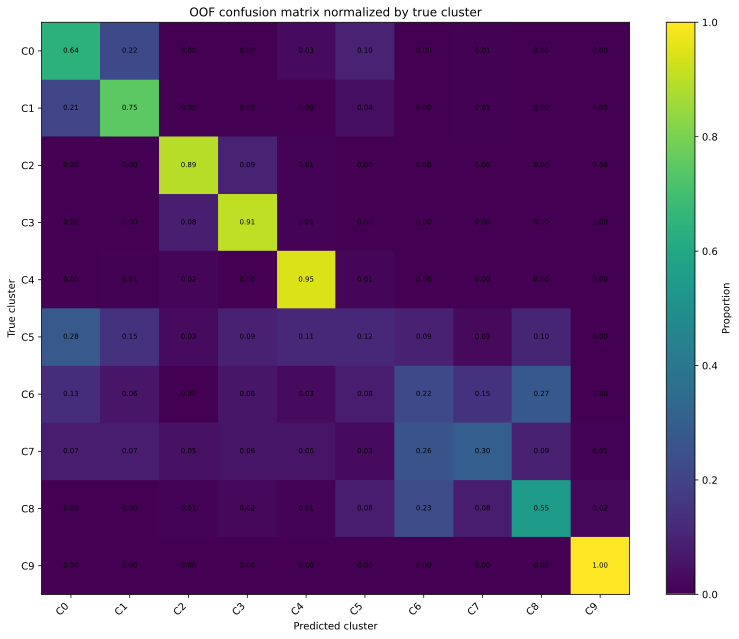

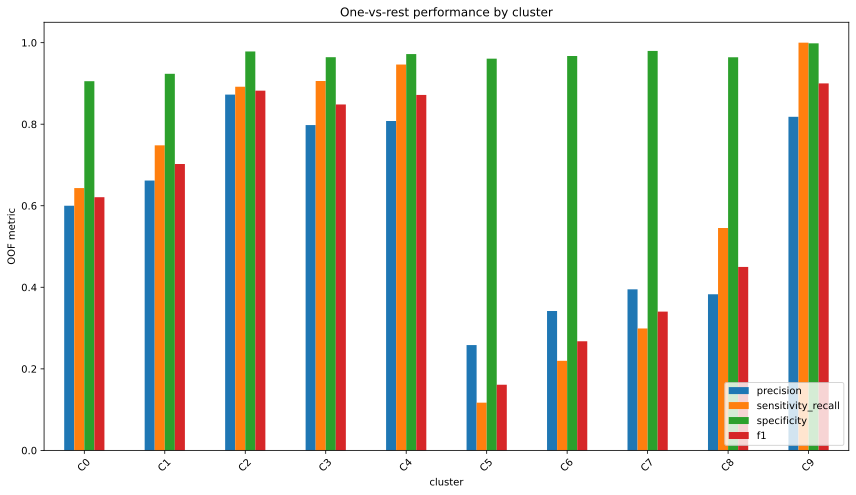

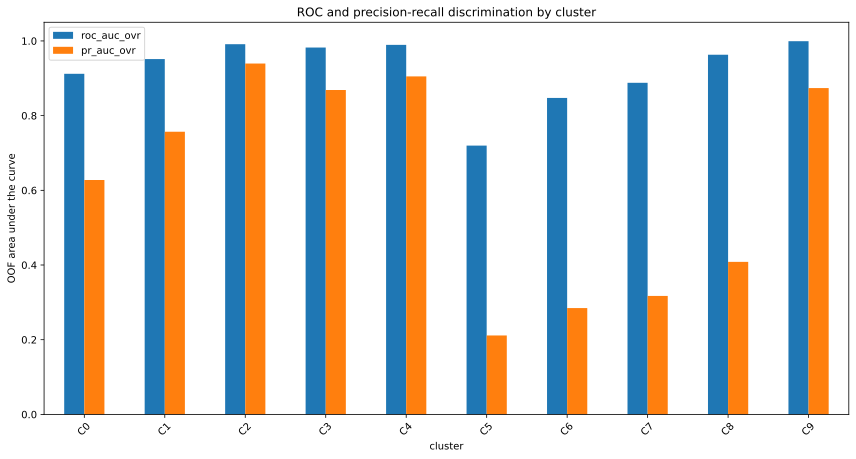

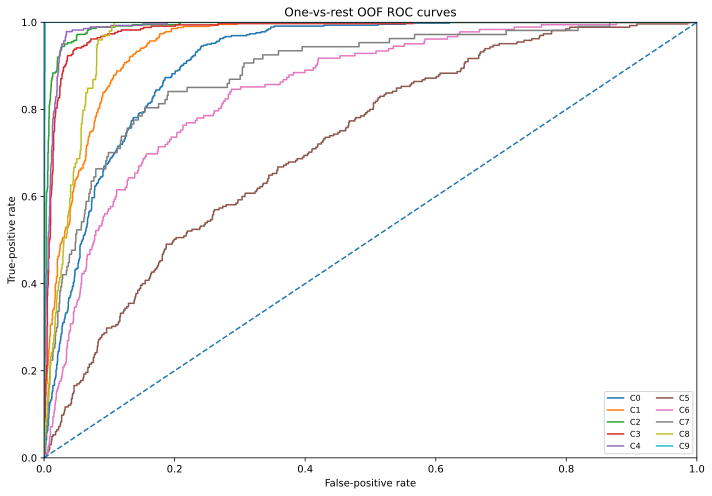

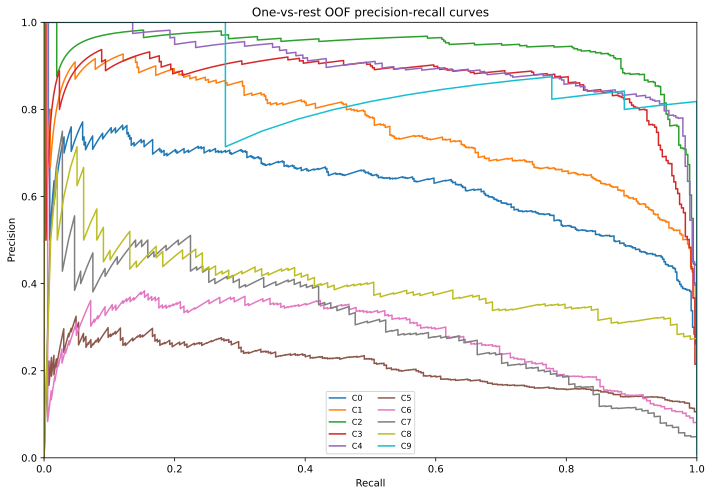

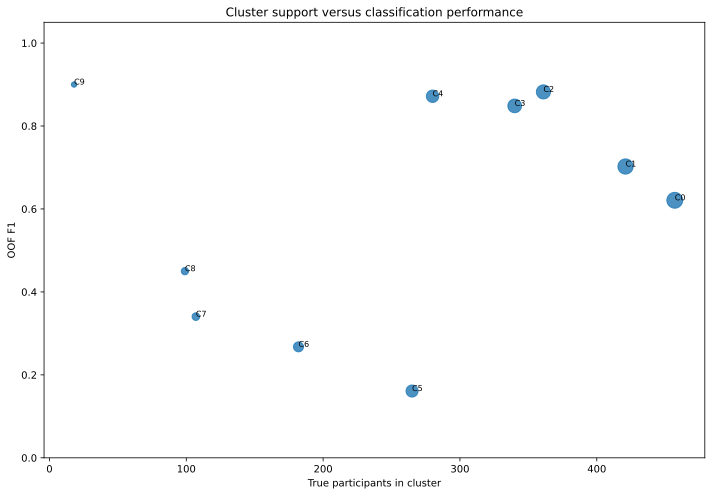

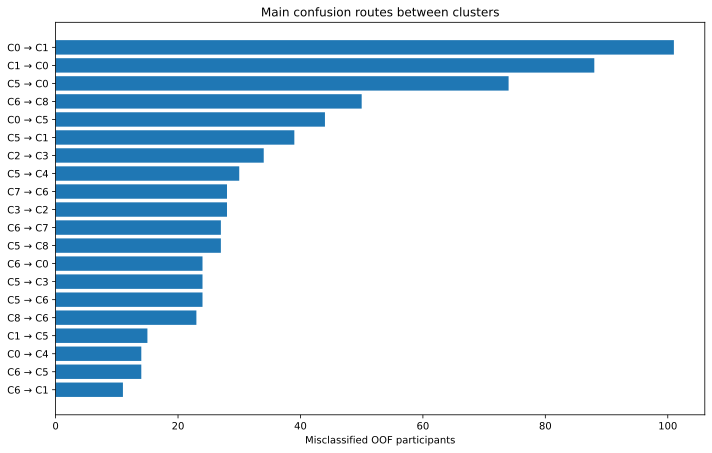

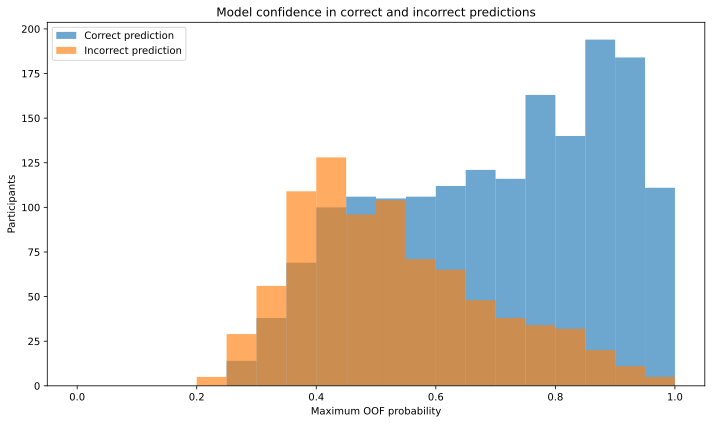

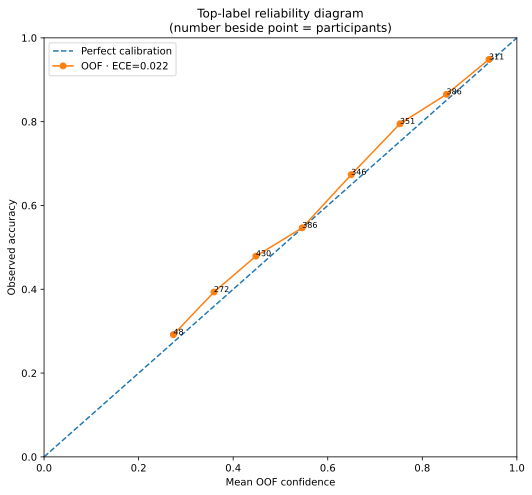

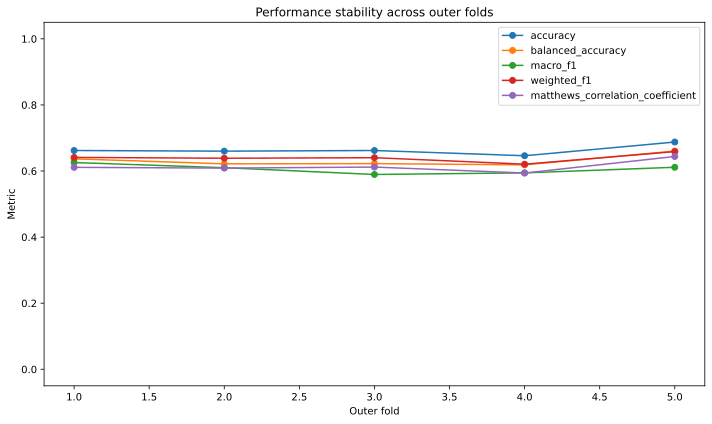

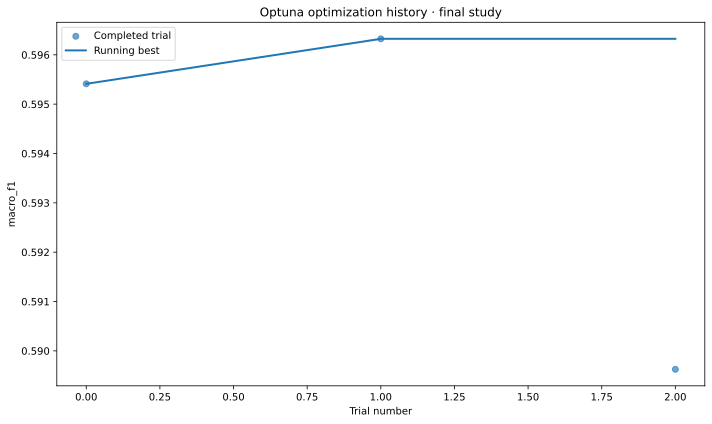

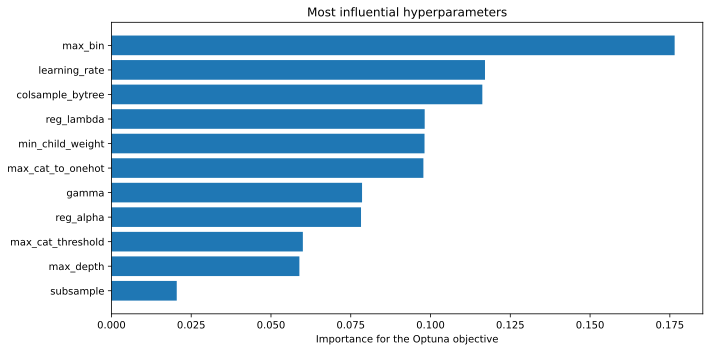

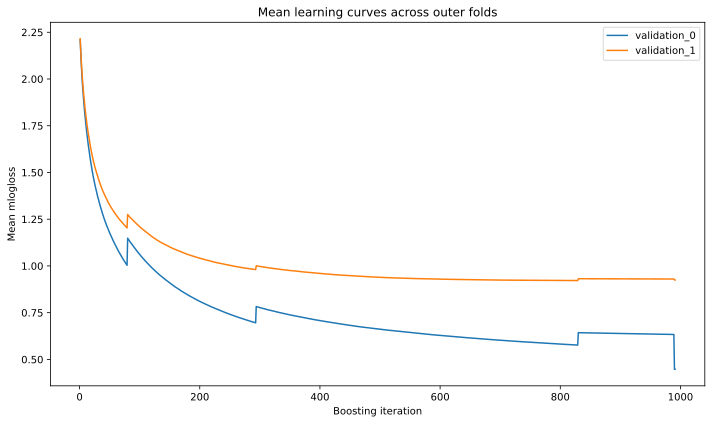

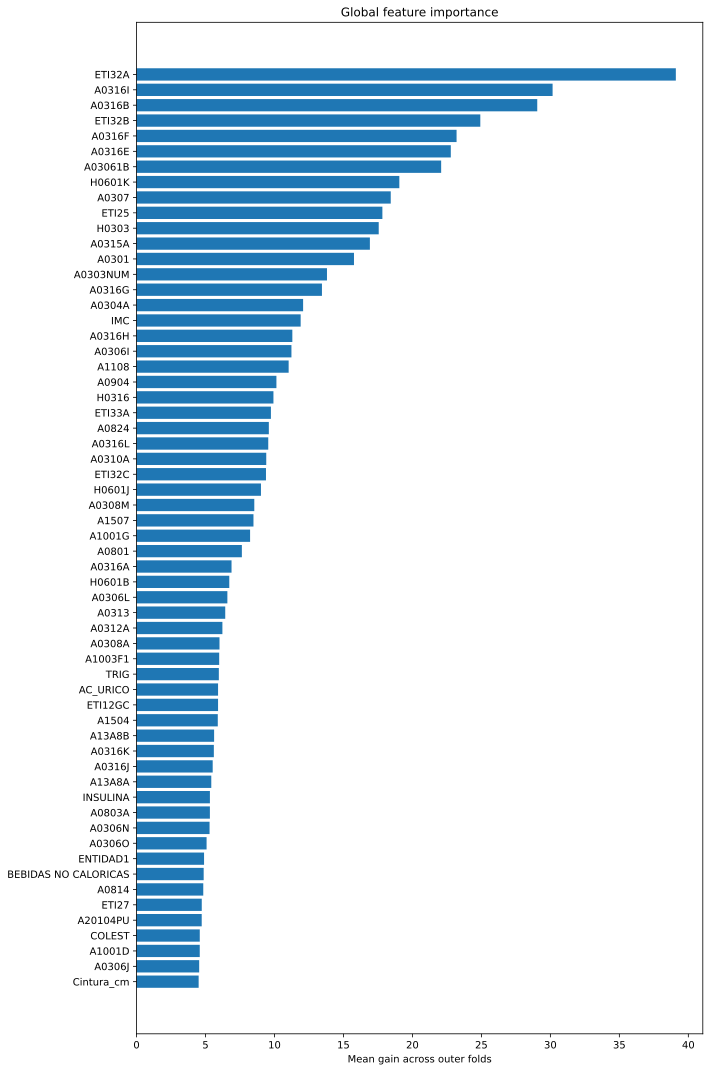

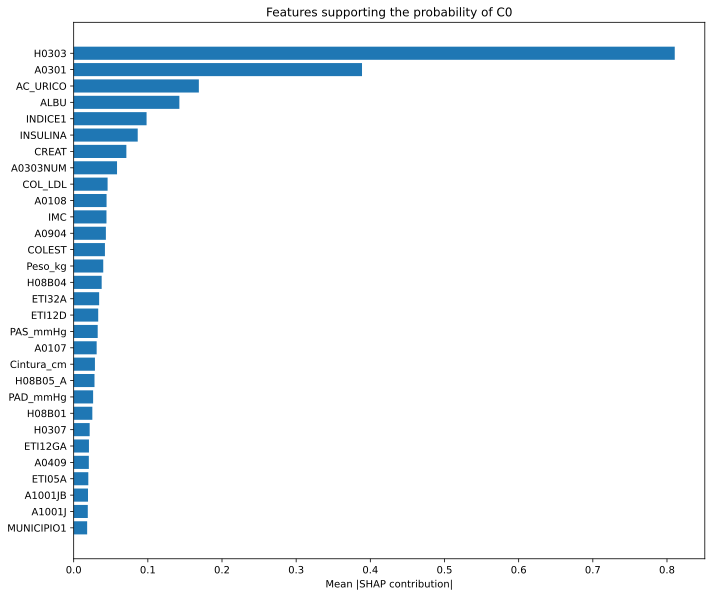

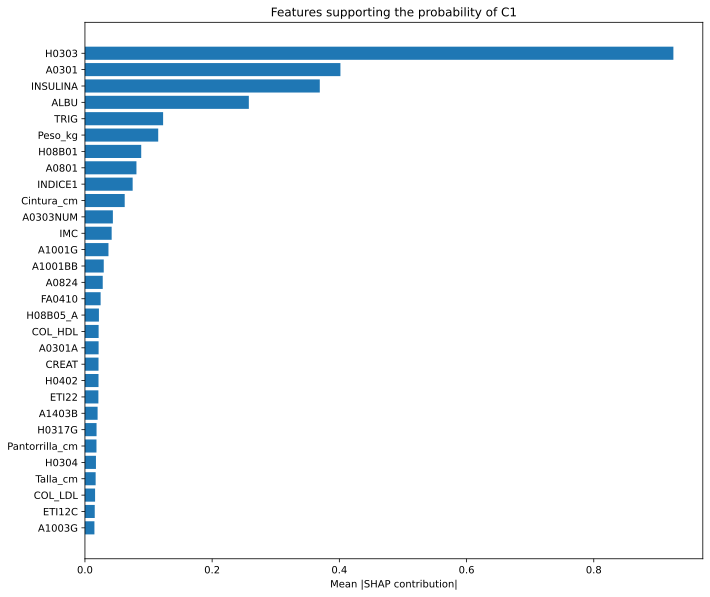

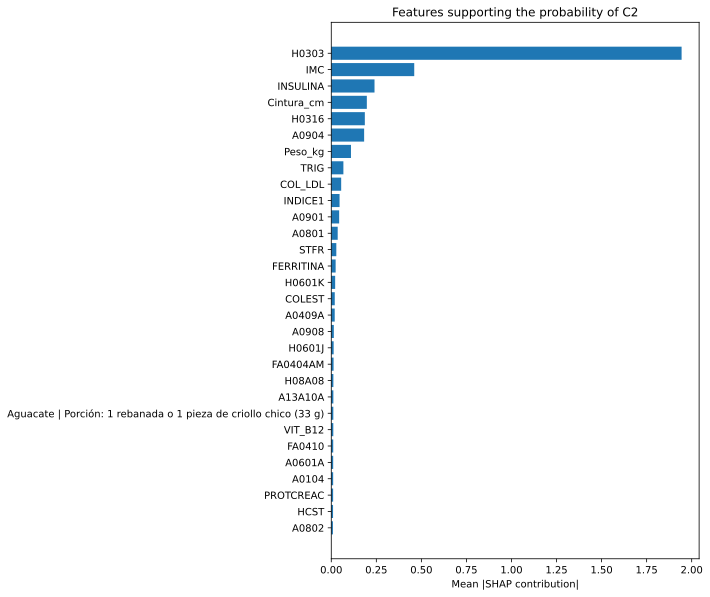

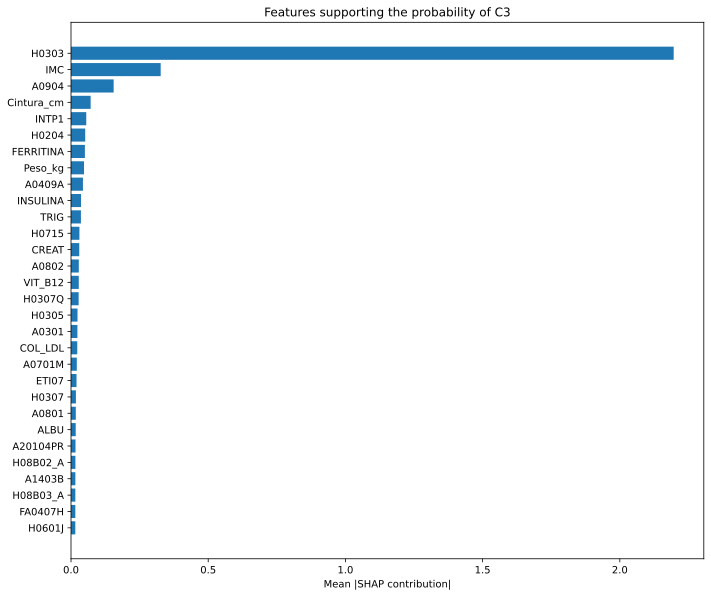

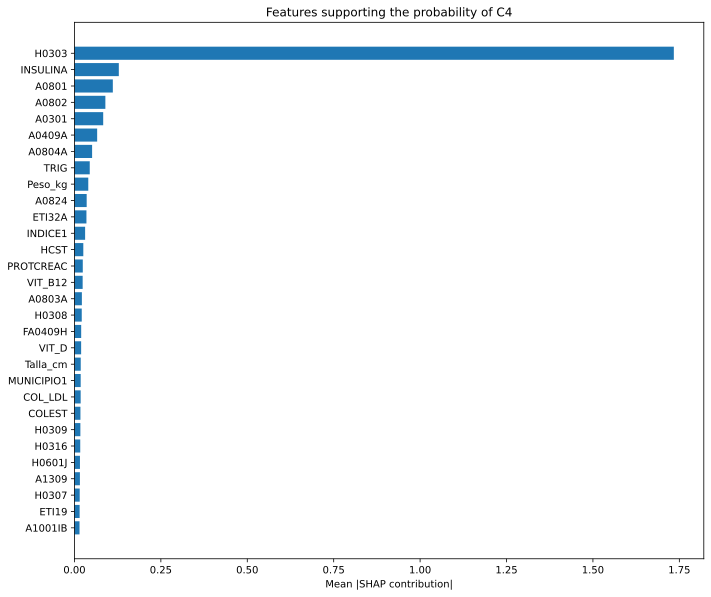

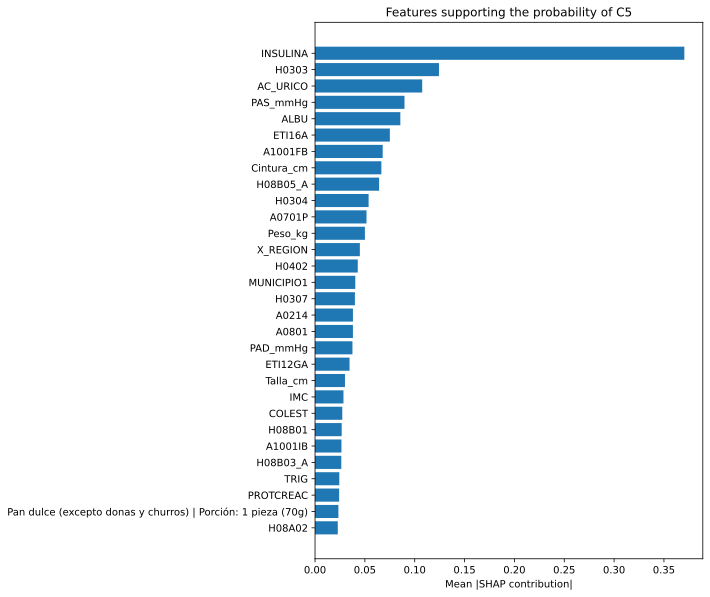

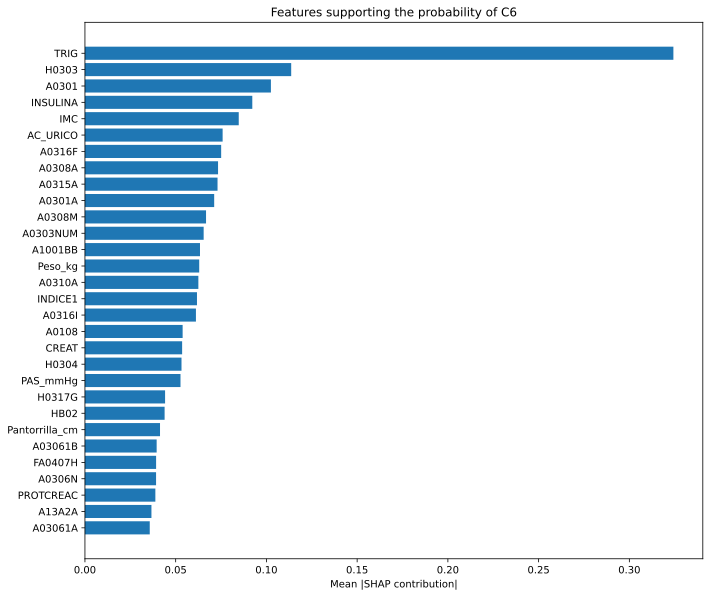

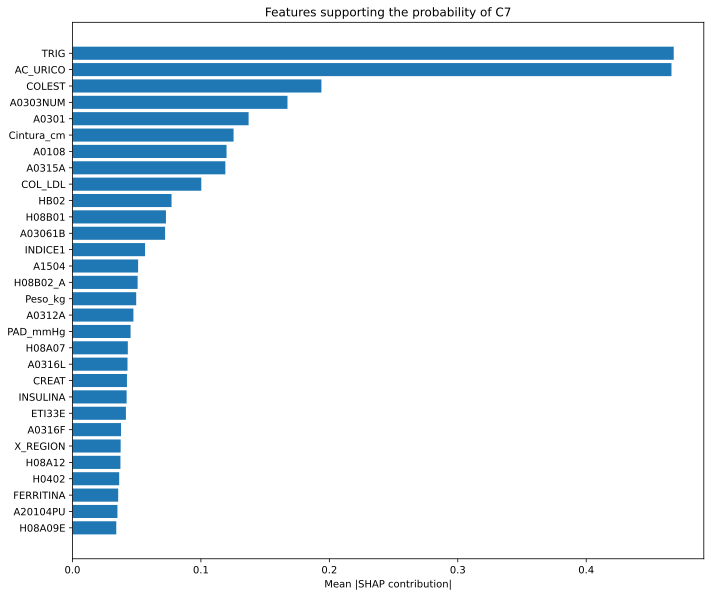

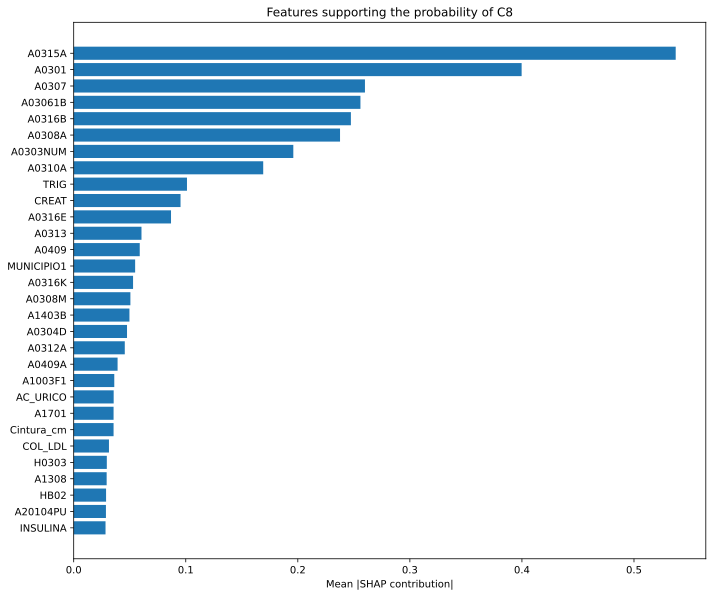

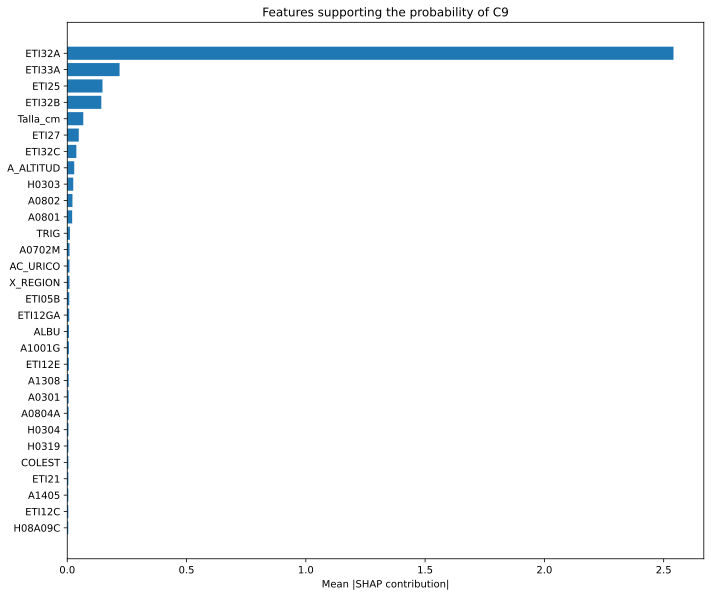


Diagnostic report:  80%|▊| 4/5 [00:10<00:02,  2.70s/stage, generate diagnostic 
Diagnostic report:  80%|▊| 4/5 [00:10<00:02,  2.70s/stage, write manifest and Z
Diagnostic report: 100%|█| 5/5 [00:10<00:00,  2.08s/stage, write manifest and Z
XGBoost workflow: 100%|█████████████| 4/4 [13:56<00:00, 209.06s/task, complete]


,participants,NB_filtered_variables,XGBoost_predictors,GLU_SUERO_in_model,clusters,report
0,2530,550,545,False,10,/Users/cristianjuliocesarpadronmanrique/Deskto...


,OOF_value
accuracy,0.663636
balanced_accuracy,0.631710
macro_precision,0.593668
macro_recall,0.631710
macro_f1,0.604466
weighted_f1,0.639930
cohen_kappa,0.611659
matthews_correlation_coefficient,0.613684
multiclass_log_loss,0.917032
macro_roc_auc_ovr,0.924394


,cluster,n_true,prevalence,n_predicted,TP,FP,FN,TN,precision,sensitivity_recall,specificity,f1,support,roc_auc_ovr,pr_auc_ovr
0,C0,457,0.180632,490,294,196,163,1877,0.600000,0.643326,0.905451,0.620908,457,0.911959,0.627616
1,C1,421,0.166403,476,315,161,106,1948,0.661765,0.748219,0.923661,0.702341,421,0.951473,0.756919
2,C2,361,0.142688,369,322,47,39,2122,0.872629,0.891967,0.978331,0.882192,361,0.991248,0.939532
3,C3,340,0.134387,386,308,78,32,2112,0.797927,0.905882,0.964384,0.848485,340,0.982282,0.868715
4,C4,280,0.110672,328,265,63,15,2187,0.807927,0.946429,0.972000,0.871711,280,0.989514,0.905097
5,C5,265,0.104743,120,31,89,234,2176,0.258333,0.116981,0.960706,0.161039,265,0.719798,0.211372
6,C6,182,0.071937,117,40,77,142,2271,0.341880,0.219780,0.967206,0.267559,182,0.847380,0.284747
7,C7,107,0.042292,81,32,49,75,2374,0.395062,0.299065,0.979777,0.340426,107,0.887862,0.317220
8,C8,99,0.039130,141,54,87,45,2344,0.382979,0.545455,0.964212,0.450000,99,0.963128,0.408348
9,C9,18,0.007115,22,18,4,0,2508,0.818182,1.000000,0.998408,0.900000,18,0.999292,0.873744


In [10]:
if RUN_XGBOOST_CROSS_VALIDATION:
    from ensanut_hba1c.io import load_ensanut_inputs
    from ensanut_hba1c.modeling import prepare_model_matrix
    from ensanut_hba1c.workflows.cluster_dataset import (
        ClusterDatasetConfig,
        prepare_cluster_dataset,
    )
    from ensanut_hba1c.workflows.progress import TaskProgress
    from ensanut_hba1c.workflows.xgboost_engine import (
        XGBoostConfig,
        run_xgboost_pipeline,
    )
    from ensanut_hba1c.workflows.xgboost_reporting import (
        XGBoostReportConfig,
        export_xgboost_results,
    )

    XGB_TASK_PROGRESS = TaskProgress(
        tasks=(
            "Load ENSANUT inputs",
            "Prepare the NB-filtered model matrix",
            "Run nested CV, Optuna, and SHAP",
            "Export metrics and diagnostic figures",
        ),
        description="XGBoost workflow",
        enabled=XGB_SHOW_PROGRESS_BARS,
        leave=XGB_PROGRESS_LEAVE,
        position=0,
    )

    XGB_TASK_PROGRESS.set_stage("load ENSANUT inputs")
    ensanut_df, model_dictionary_df = load_ensanut_inputs(
        PATHS.input_dir,
        data_filename="ENSANUT_2024_mx.csv",
        dictionary_filename="ENSANUT_2024.csv",
    )
    XGB_TASK_PROGRESS.complete("inputs loaded")

    MODEL_EXCLUDE_COLUMNS = sorted(set(
        REDUNDANT_AGE_COLUMNS
        + TARGET_DERIVED_COLUMNS
        + DIRECT_OUTCOME_OR_LEAKAGE_COLUMNS
        + NOTEBOOK2_EXCLUDE_VARIABLES
        + ["_merge"]
    ))
    FORBIDDEN_PREDICTORS = sorted(set(
        NB_FRAMEWORK_EXCLUDE_VARIABLES
        + NOTEBOOK2_EXCLUDE_VARIABLES
        + list(ID_COLUMNS)
        + [CLUSTER_COLUMN, "HB1AC", "_merge"]
    ))

    XGB_TASK_PROGRESS.set_stage("prepare NB-filtered predictors")
    PREPARED_CLUSTER_DATASET = prepare_cluster_dataset(
        ensanut_df,
        cluster_df,
        prepare_model_matrix_fn=prepare_model_matrix,
        evidence=NB_EVIDENCE,
        config=ClusterDatasetConfig(
            target_column_for_cohort="HB1AC",
            weight_column=None,
            id_columns=tuple(ID_COLUMNS),
            cluster_column=CLUSTER_COLUMN,
            max_categorical_levels=100,
            max_nb_features=NB_MAX_PREDICTORS,
        ),
        model_exclude_columns=MODEL_EXCLUDE_COLUMNS,
        forbidden_predictors=FORBIDDEN_PREDICTORS,
    )

    assert set(PREPARED_CLUSTER_DATASET.X.columns).issubset(
        set(NB_FILTERED_VARIABLES)
    ), "XGBoost contains variables outside the NB-filtered evidence set."

    GLUCOSE_COLUMNS_IN_MODEL = [
        column
        for column in PREPARED_CLUSTER_DATASET.X.columns
        if (
            "GLU_SUERO" in str(column).upper()
            or "GLUC_SUERO" in str(column).upper()
        )
    ]
    if GLUCOSE_COLUMNS_IN_MODEL:
        raise AssertionError(
            "Serum-glucose columns entered XGBoost: "
            + ", ".join(map(str, GLUCOSE_COLUMNS_IN_MODEL))
        )
    print("Verified: GLU_SUERO is absent from the XGBoost matrix.")
    XGB_TASK_PROGRESS.complete("model matrix ready")

    XGB_OUTPUT_DIR = (
        PATHS.notebook2_results
        / "xgboost_cluster_classification_cv_no_GLU_SUERO"
    )
    XGB_TASK_PROGRESS.set_stage("nested CV, Optuna, and SHAP")
    XGB_RESULT = run_xgboost_pipeline(
        X=PREPARED_CLUSTER_DATASET.X,
        y=PREPARED_CLUSTER_DATASET.y,
        sample_weights=PREPARED_CLUSTER_DATASET.sample_weights,
        output_dir=XGB_OUTPUT_DIR,
        config=XGBoostConfig(
            random_state=XGB_RANDOM_STATE,
            outer_cv_splits=XGB_CV_N_SPLITS,
            inner_cv_splits=OPTUNA_INNER_CV_SPLITS,
            run_optuna=RUN_OPTUNA_HYPERPARAMETER_SEARCH,
            trials_per_outer_fold=OPTUNA_TRIALS_PER_OUTER_FOLD,
            final_trials=OPTUNA_FINAL_N_TRIALS,
            optuna_timeout_seconds=OPTUNA_TIMEOUT_SECONDS,
            optuna_study_basename=OPTUNA_STUDY_BASENAME,
            reuse_existing_studies=OPTUNA_REUSE_EXISTING_STUDIES,
            optuna_startup_trials=OPTUNA_N_STARTUP_TRIALS,
            optuna_pruner_startup_trials=OPTUNA_PRUNER_STARTUP_TRIALS,
            optuna_pruner_warmup_steps=OPTUNA_PRUNER_WARMUP_STEPS,
            objective_metric=OPTUNA_OBJECTIVE_METRIC,
            optuna_n_jobs=OPTUNA_N_JOBS,
            max_estimators=XGB_MAX_ESTIMATORS,
            early_stopping_rounds=XGB_EARLY_STOPPING_ROUNDS,
            tree_method=XGB_TREE_METHOD,
            n_jobs=XGB_N_JOBS,
            use_balanced_class_weights=XGB_USE_BALANCED_CLASS_WEIGHTS,
            shap_max_rows_per_fold=XGB_SHAP_MAX_ROWS_PER_FOLD,
            learning_rate_min=OPTUNA_LEARNING_RATE_MIN,
            learning_rate_max=OPTUNA_LEARNING_RATE_MAX,
            max_depth_min=OPTUNA_MAX_DEPTH_MIN,
            max_depth_max=OPTUNA_MAX_DEPTH_MAX,
            min_child_weight_min=OPTUNA_MIN_CHILD_WEIGHT_MIN,
            min_child_weight_max=OPTUNA_MIN_CHILD_WEIGHT_MAX,
            subsample_min=OPTUNA_SUBSAMPLE_MIN,
            subsample_max=OPTUNA_SUBSAMPLE_MAX,
            colsample_bytree_min=OPTUNA_COLSAMPLE_BYTREE_MIN,
            colsample_bytree_max=OPTUNA_COLSAMPLE_BYTREE_MAX,
            gamma_min=OPTUNA_GAMMA_MIN,
            gamma_max=OPTUNA_GAMMA_MAX,
            reg_alpha_min=OPTUNA_REG_ALPHA_MIN,
            reg_alpha_max=OPTUNA_REG_ALPHA_MAX,
            reg_lambda_min=OPTUNA_REG_LAMBDA_MIN,
            reg_lambda_max=OPTUNA_REG_LAMBDA_MAX,
            max_bin_options=tuple(OPTUNA_MAX_BIN_OPTIONS),
            max_cat_to_onehot_options=tuple(OPTUNA_MAX_CAT_TO_ONEHOT_OPTIONS),
            max_cat_threshold_options=tuple(OPTUNA_MAX_CAT_THRESHOLD_OPTIONS),
            show_progress_bars=XGB_SHOW_PROGRESS_BARS,
            progress_leave=XGB_PROGRESS_LEAVE,
        ),
    )
    XGB_TASK_PROGRESS.complete("nested CV complete")

    XGB_TASK_PROGRESS.set_stage("export diagnostic report")
    XGB_OUTPUTS = export_xgboost_results(
        XGB_RESULT,
        XGB_OUTPUT_DIR,
        participant_keys=PREPARED_CLUSTER_DATASET.participant_keys,
        feature_selection_audit=PREPARED_CLUSTER_DATASET.feature_selection.audit,
        model_audit=PREPARED_CLUSTER_DATASET.model_audit,
        config=XGBoostReportConfig(
            dpi=XGB_REPORT_DPI,
            top_global_features=XGB_TOP_FEATURES_GLOBAL,
            top_features_per_cluster=XGB_TOP_FEATURES_PER_CLUSTER,
            top_confusion_pairs=XGB_TOP_CONFUSION_PAIRS,
            top_optuna_parameters=XGB_TOP_OPTUNA_PARAMETERS,
            calibration_bins=XGB_CALIBRATION_BINS,
            save_individual_plots=XGB_SAVE_INDIVIDUAL_PLOTS,
            show_in_notebook=XGB_SHOW_ALL_DIAGNOSTIC_FIGURES,
            show_summary_page_in_notebook=False,
            verbose=False,
            show_progress_bars=XGB_SHOW_PROGRESS_BARS,
            progress_leave=XGB_PROGRESS_LEAVE,
        ),
    )
    PREPARED_CLUSTER_DATASET.feature_selection.export(
        XGB_OUTPUT_DIR / "feature_selection"
    )
    XGB_TASK_PROGRESS.complete("reports exported")
    XGB_TASK_PROGRESS.close("complete")

    display(pd.DataFrame([{
        "participants": len(PREPARED_CLUSTER_DATASET.X),
        "NB_filtered_variables": len(NB_FILTERED_VARIABLES),
        "XGBoost_predictors": PREPARED_CLUSTER_DATASET.X.shape[1],
        "GLU_SUERO_in_model": False,
        "clusters": PREPARED_CLUSTER_DATASET.y.nunique(),
        "report": str(XGB_OUTPUTS["pdf"]),
    }]))
    display(XGB_RESULT.global_metrics.T.rename(columns={0: "OOF_value"}))
    display(XGB_RESULT.metrics_by_cluster)
else:
    print("XGBoost cross-validation is disabled.")


## 10. XGBoost prediction after merging C5–C8, without GLU_SUERO

C5, C6, C7, and C8 are relabeled as one class (`C5-C8`). The classifier is then trained again from scratch with the same no-glucose predictors, nested cross-validation, Optuna search, SHAP diagnostics, and reporting settings used for the original ten-cluster target. Outputs are written to a separate folder.


,cluster,participants
0,C5-C8,653
1,C0,457
2,C1,421
3,C2,361
4,C3,340
5,C4,280
6,C9,18


Merged C5-C8 XGBoost workflow:  33%|▎| 1/3 [00:00<00:00, 2624.72task/s, nested 
XGBoost pipeline:   0%|      | 0/8 [00:00<?, ?stage/s, outer fold 1/5 · Optuna]

Optuna · outer fold 1:   0%|                          | 0/8 [00:00<?, ?trial/s]

Optuna · outer fold 1:   0%| | 0/8 [00:00<?, ?trial/s, trial=1, inner fold=1/2]

Optuna · outer fold 1:   0%| | 0/8 [00:13<?, ?trial/s, trial=1, inner fold=2/2]

Optuna · outer fold 1:  12%|▏| 1/8 [00:28<03:16, 28.12s/trial, trial=1, inner f

Optuna · outer fold 1:  12%|▏| 1/8 [00:28<03:16, 28.12s/trial, trial=1, score=0

Optuna · outer fold 1:  12%|▏| 1/8 [00:28<03:16, 28.12s/trial, trial=2, inner f

Optuna · outer fold 1:  12%|▏| 1/8 [00:30<03:16, 28.12s/trial, trial=2, inner f

Optuna · outer fold 1:  25%|▎| 2/8 [00:32<01:23, 13.91s/trial, trial=2, inner f

Optuna · outer fold 1:  25%|▎| 2/8 [00:32<01:23, 13.91s/trial, trial=2, score=0

Optuna · outer fold 1:  25%|▎| 2/8 [00:32<01:23, 13.91s/trial, trial=3, inner f

Optuna · outer fold 1:  25%|▎

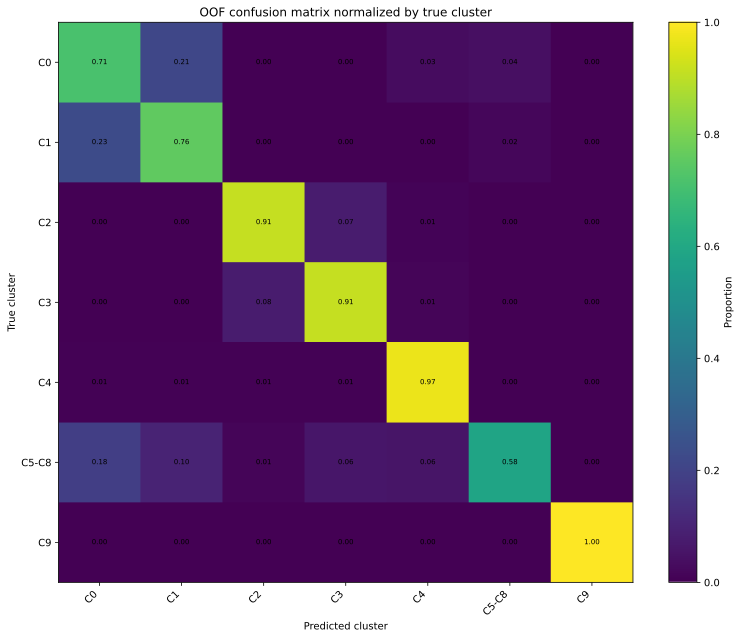

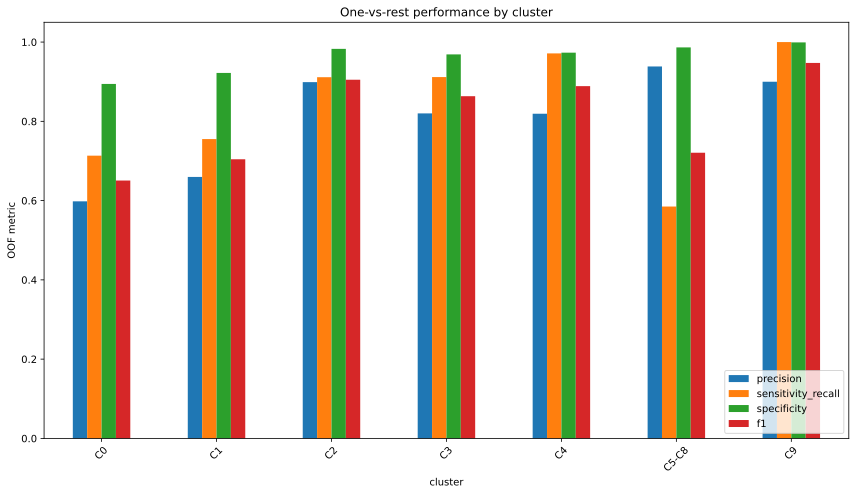

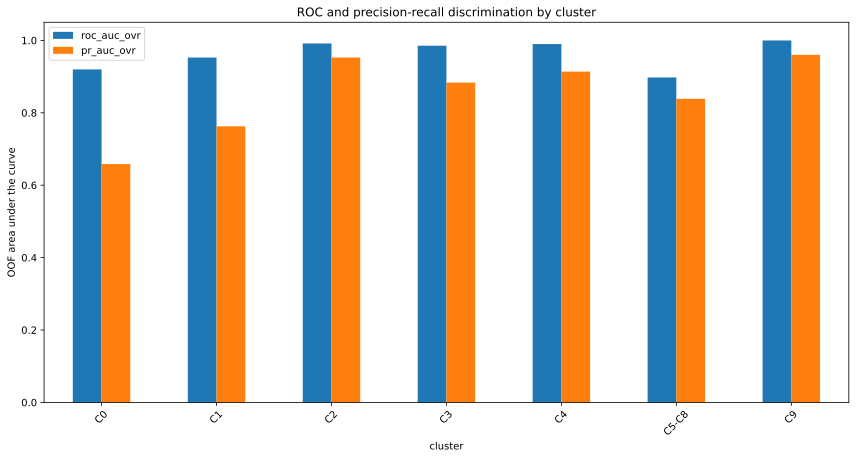

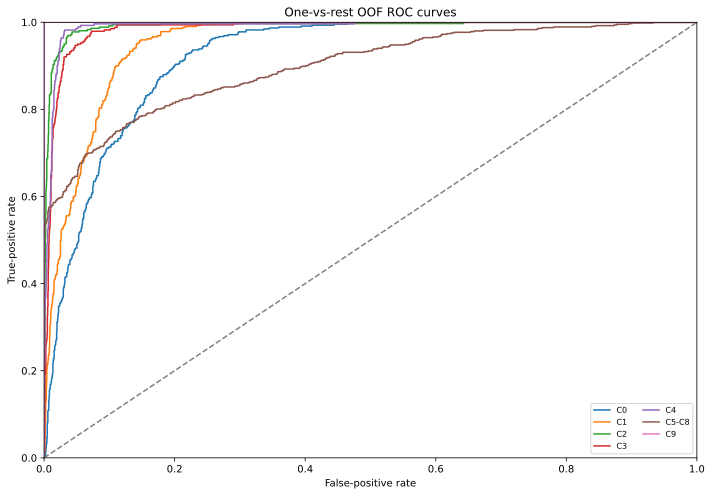

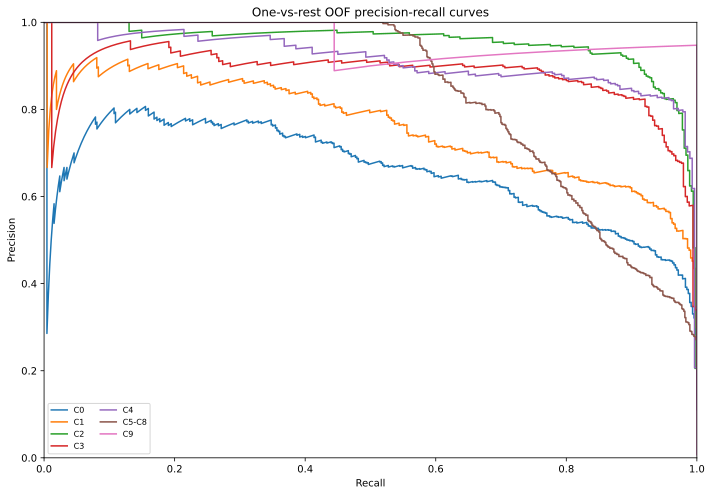

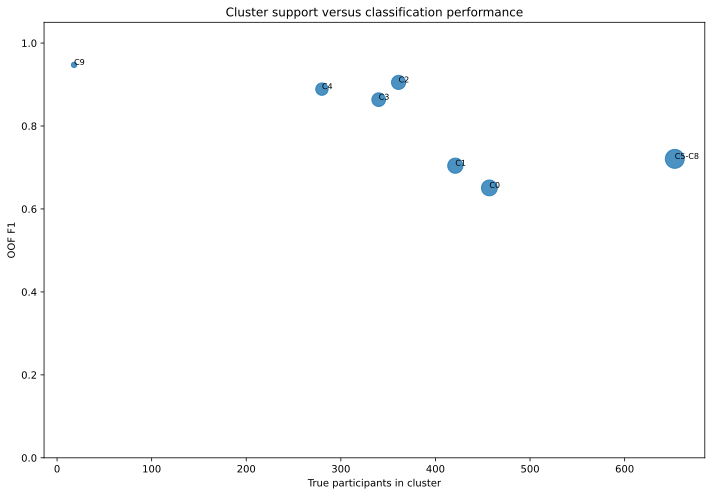

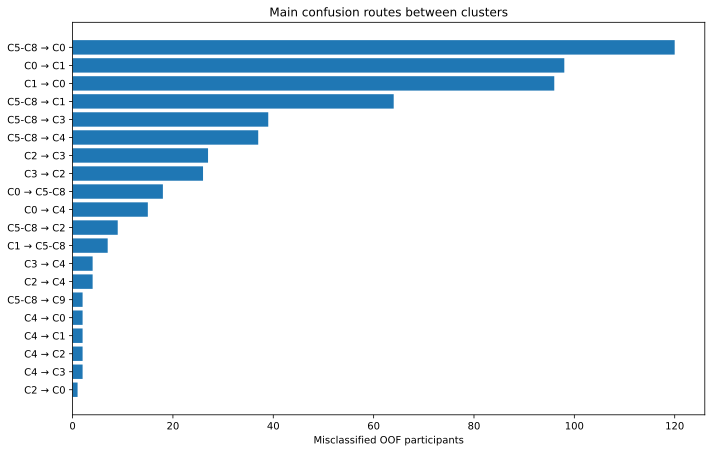

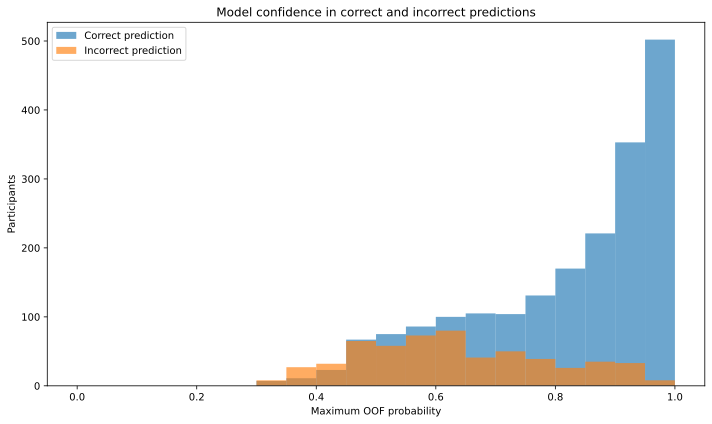

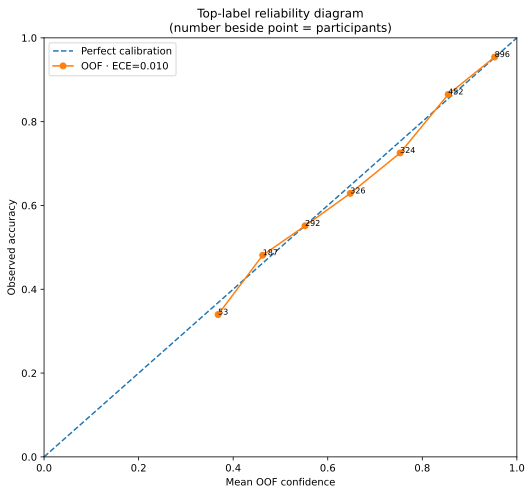

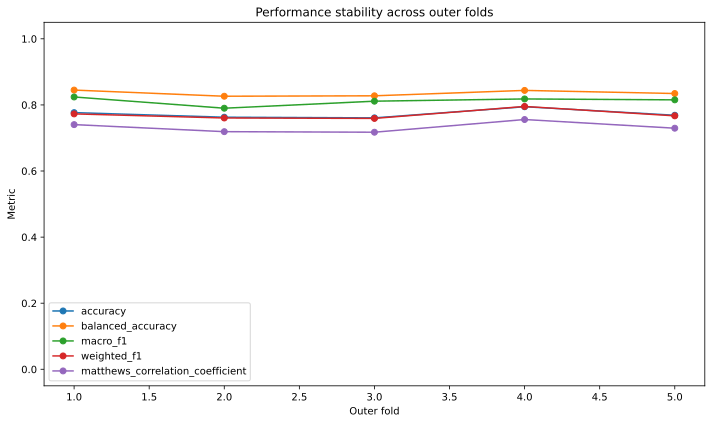

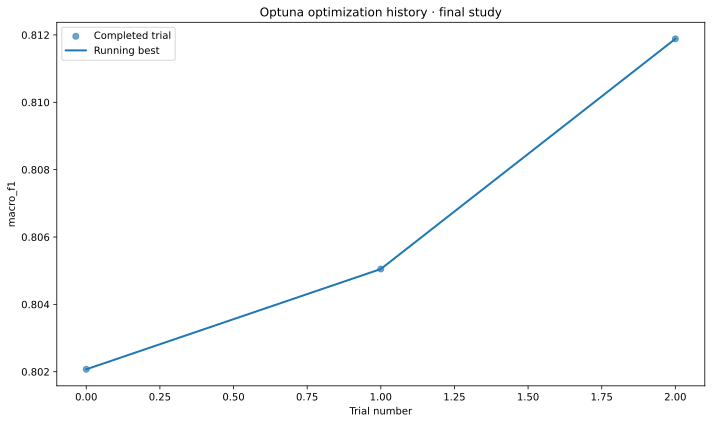

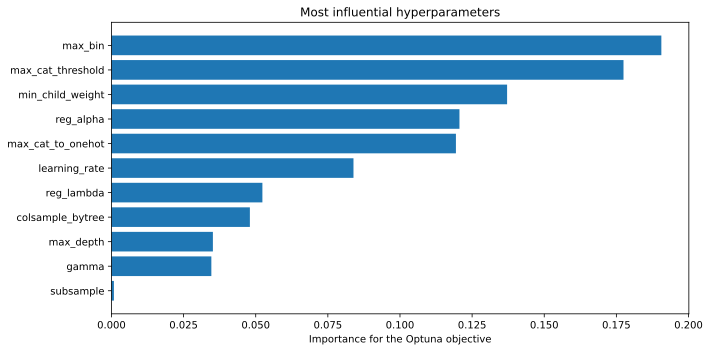

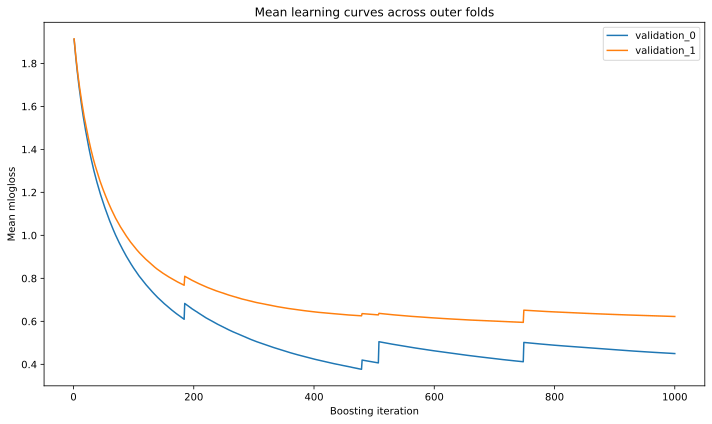

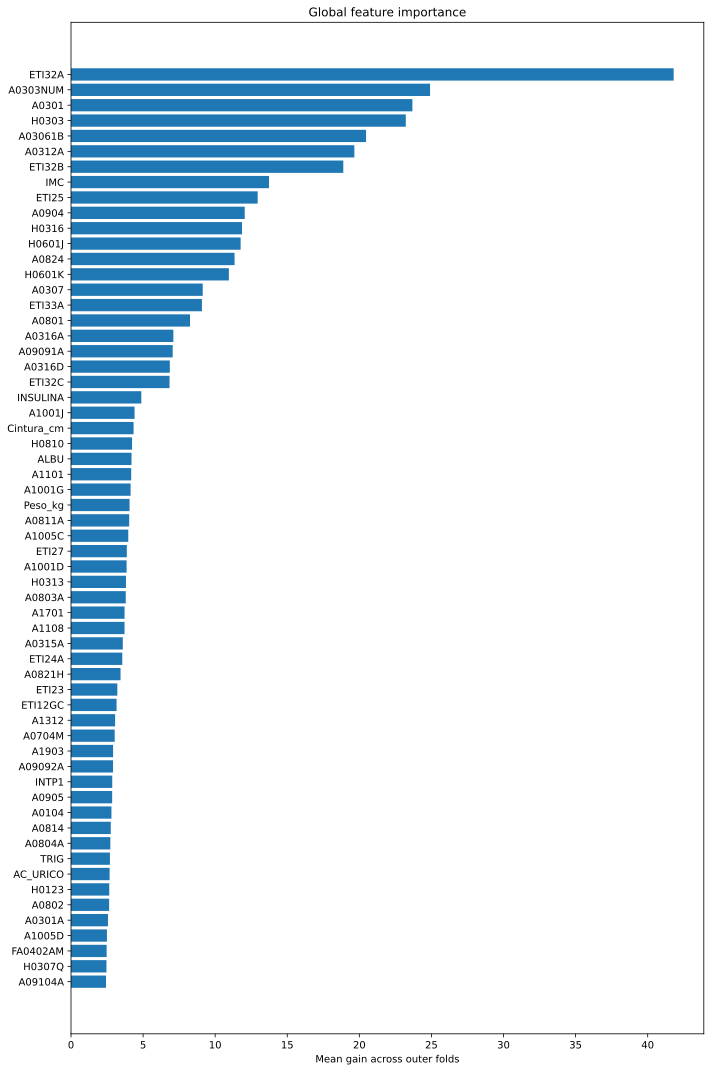

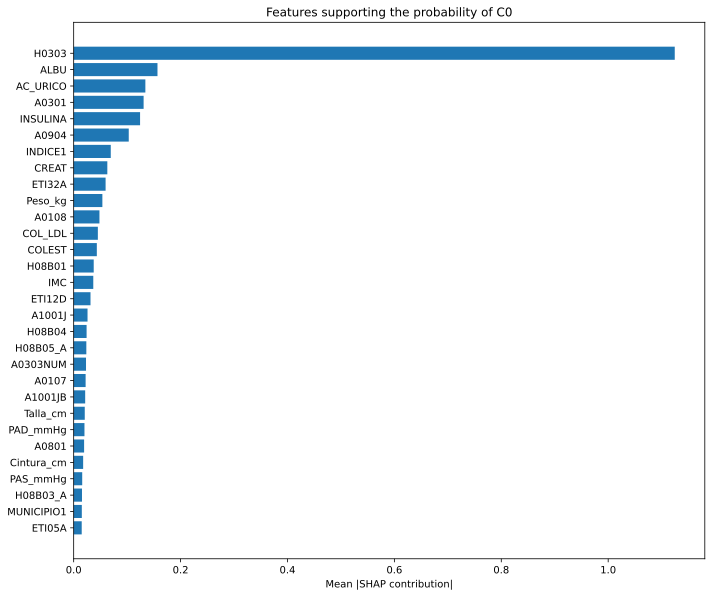

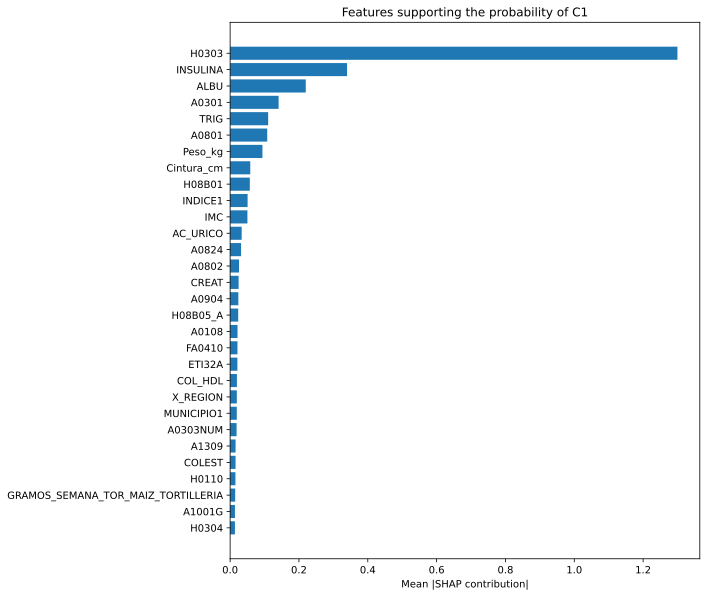

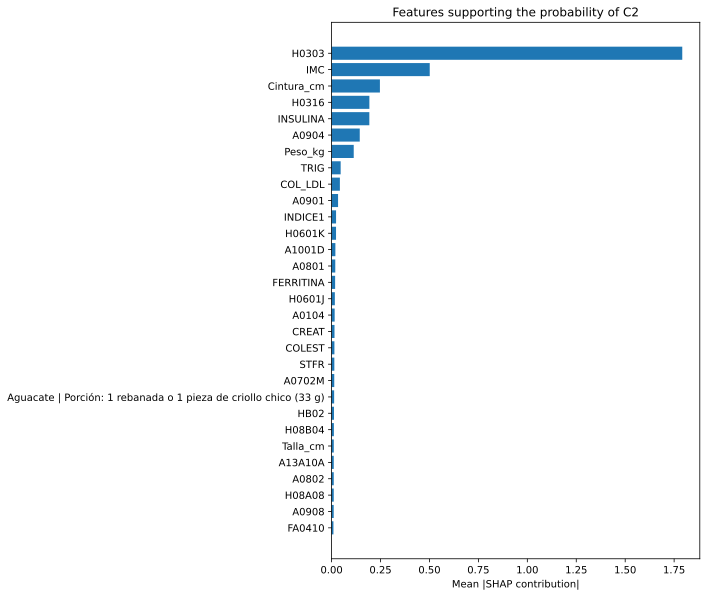

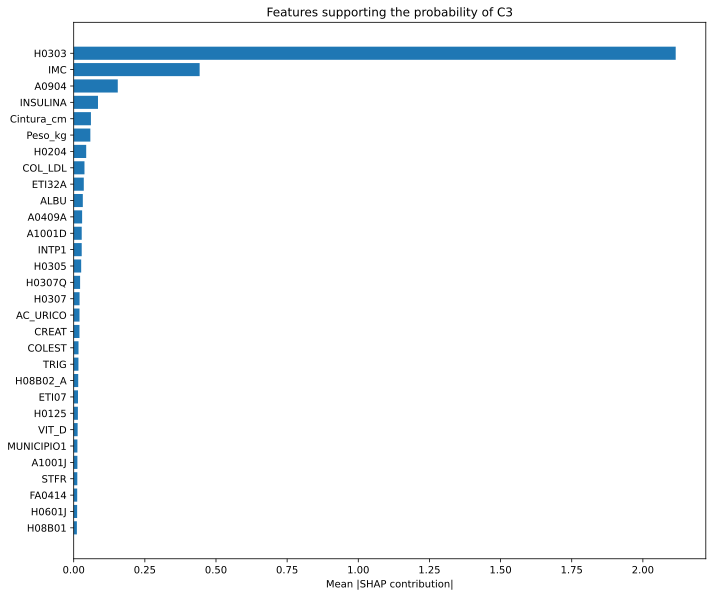

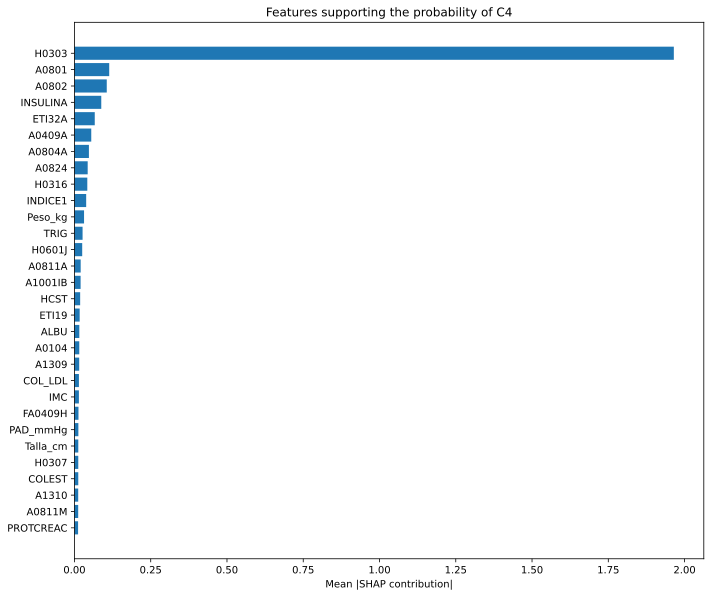

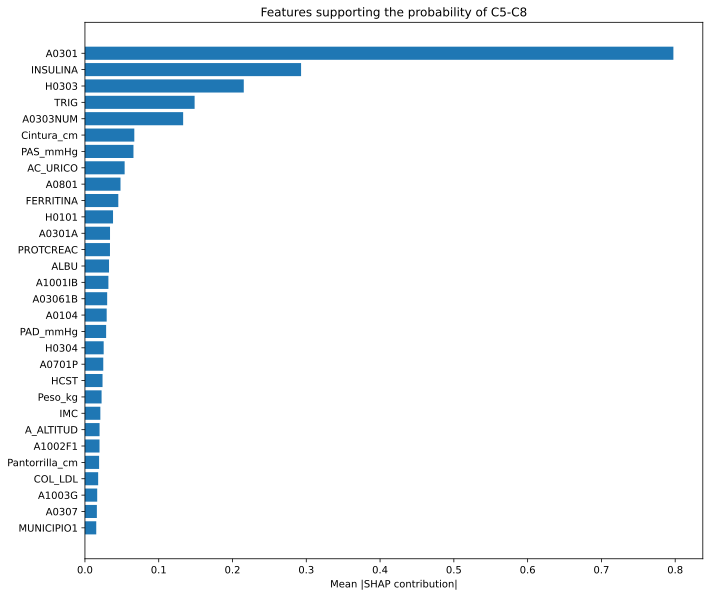

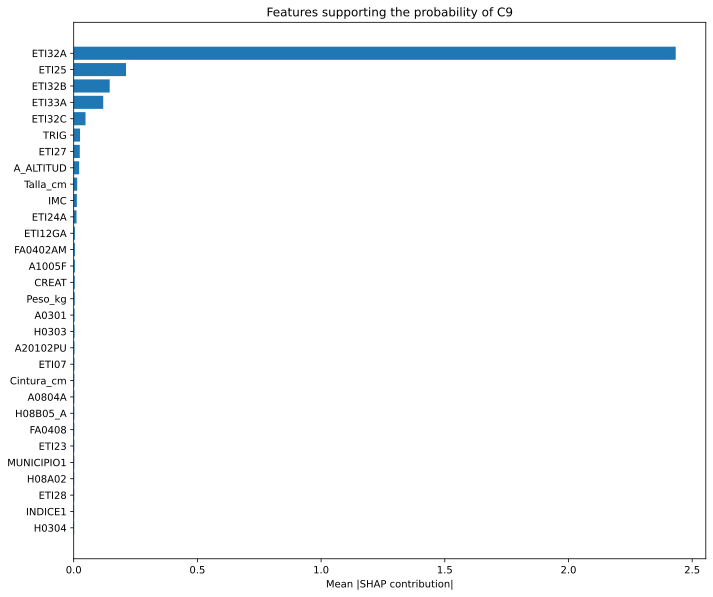


Diagnostic report:  80%|▊| 4/5 [00:08<00:02,  2.17s/stage, generate diagnostic 
Diagnostic report:  80%|▊| 4/5 [00:08<00:02,  2.17s/stage, write manifest and Z
Diagnostic report: 100%|█| 5/5 [00:08<00:00,  1.68s/stage, write manifest and Z
Diagnostic report: 100%|████████████| 5/5 [00:08<00:00,  1.75s/stage, complete]
Merged C5-C8 XGBoost workflow: 100%|█| 3/3 [12:56<00:00, 258.80s/task, complete


,participants,NB_filtered_variables,XGBoost_predictors,GLU_SUERO_in_model,original_clusters,merged_classes,merged_label,report
0,2530,550,545,False,10,7,C5-C8,/Users/cristianjuliocesarpadronmanrique/Deskto...


,OOF_value
accuracy,0.772727
balanced_accuracy,0.835462
macro_precision,0.804969
macro_recall,0.835462
macro_f1,0.811518
weighted_f1,0.771072
cohen_kappa,0.727022
matthews_correlation_coefficient,0.732264
multiclass_log_loss,0.593091
macro_roc_auc_ovr,0.962313


,cluster,n_true,prevalence,n_predicted,TP,FP,FN,TN,precision,sensitivity_recall,specificity,f1,support,roc_auc_ovr,pr_auc_ovr
0,C0,457,0.180632,545,326,219,131,1854,0.598165,0.713348,0.894356,0.650699,457,0.919832,0.658417
1,C1,421,0.166403,482,318,164,103,1945,0.659751,0.755344,0.922238,0.704319,421,0.952590,0.762604
2,C2,361,0.142688,366,329,37,32,2132,0.898907,0.911357,0.982941,0.905089,361,0.991434,0.952584
3,C3,340,0.134387,378,310,68,30,2122,0.820106,0.911765,0.968950,0.863510,340,0.985197,0.883293
4,C4,280,0.110672,332,272,60,8,2190,0.819277,0.971429,0.973333,0.888889,280,0.989862,0.913705
5,C5-C8,653,0.258103,407,382,25,271,1852,0.938575,0.584992,0.986681,0.720755,653,0.897497,0.838707
6,C9,18,0.007115,20,18,2,0,2510,0.900000,1.000000,0.999204,0.947368,18,0.999779,0.960068


In [11]:
if RUN_XGBOOST_CROSS_VALIDATION and RUN_MERGED_CLUSTER_CROSS_VALIDATION:
    if "PREPARED_CLUSTER_DATASET" not in globals():
        raise RuntimeError(
            "Run the original 10-cluster XGBoost cell before this cell."
        )

    if GLUCOSE_COLUMNS_IN_MODEL:
        raise AssertionError(
            "The merged model received a serum-glucose predictor."
        )

    original_cluster_labels = PREPARED_CLUSTER_DATASET.y.astype(str)
    observed_cluster_labels = set(original_cluster_labels.unique())
    missing_merged_clusters = (
        set(MERGED_CLUSTER_MEMBERS) - observed_cluster_labels
    )
    if missing_merged_clusters:
        raise ValueError(
            "Cannot merge absent clusters: "
            + ", ".join(sorted(missing_merged_clusters))
        )

    MERGED_CLUSTER_Y = original_cluster_labels.replace(
        {cluster: MERGED_CLUSTER_LABEL for cluster in MERGED_CLUSTER_MEMBERS}
    )
    expected_merged_class_count = (
        original_cluster_labels.nunique() - len(MERGED_CLUSTER_MEMBERS) + 1
    )
    if MERGED_CLUSTER_Y.nunique() != expected_merged_class_count:
        raise AssertionError(
            "Unexpected number of classes after merging C5-C8."
        )

    merged_class_counts = (
        MERGED_CLUSTER_Y.value_counts()
        .rename_axis("cluster")
        .reset_index(name="participants")
    )
    display(merged_class_counts)

    MERGED_XGB_OUTPUT_DIR = (
        PATHS.notebook2_results
        / "xgboost_cluster_classification_cv_C5_C8_merged_no_GLU_SUERO"
    )

    MERGED_XGB_TASK_PROGRESS = TaskProgress(
        tasks=(
            "Validate C5-C8 merged labels",
            "Run nested CV, Optuna, and SHAP",
            "Export metrics and diagnostic figures",
        ),
        description="Merged C5-C8 XGBoost workflow",
        enabled=XGB_SHOW_PROGRESS_BARS,
        leave=XGB_PROGRESS_LEAVE,
        position=0,
    )
    MERGED_XGB_TASK_PROGRESS.complete("merged labels ready")

    MERGED_XGB_TASK_PROGRESS.set_stage(
        "nested CV, Optuna, and SHAP"
    )
    MERGED_XGB_RESULT = run_xgboost_pipeline(
        X=PREPARED_CLUSTER_DATASET.X,
        y=MERGED_CLUSTER_Y,
        sample_weights=PREPARED_CLUSTER_DATASET.sample_weights,
        output_dir=MERGED_XGB_OUTPUT_DIR,
        config=XGBoostConfig(
            random_state=XGB_RANDOM_STATE,
            outer_cv_splits=XGB_CV_N_SPLITS,
            inner_cv_splits=OPTUNA_INNER_CV_SPLITS,
            run_optuna=RUN_OPTUNA_HYPERPARAMETER_SEARCH,
            trials_per_outer_fold=OPTUNA_TRIALS_PER_OUTER_FOLD,
            final_trials=OPTUNA_FINAL_N_TRIALS,
            optuna_timeout_seconds=OPTUNA_TIMEOUT_SECONDS,
            optuna_study_basename=(
                f"{OPTUNA_STUDY_BASENAME}_C5_C8_merged"
            ),
            reuse_existing_studies=OPTUNA_REUSE_EXISTING_STUDIES,
            optuna_startup_trials=OPTUNA_N_STARTUP_TRIALS,
            optuna_pruner_startup_trials=OPTUNA_PRUNER_STARTUP_TRIALS,
            optuna_pruner_warmup_steps=OPTUNA_PRUNER_WARMUP_STEPS,
            objective_metric=OPTUNA_OBJECTIVE_METRIC,
            optuna_n_jobs=OPTUNA_N_JOBS,
            max_estimators=XGB_MAX_ESTIMATORS,
            early_stopping_rounds=XGB_EARLY_STOPPING_ROUNDS,
            tree_method=XGB_TREE_METHOD,
            n_jobs=XGB_N_JOBS,
            use_balanced_class_weights=XGB_USE_BALANCED_CLASS_WEIGHTS,
            shap_max_rows_per_fold=XGB_SHAP_MAX_ROWS_PER_FOLD,
            learning_rate_min=OPTUNA_LEARNING_RATE_MIN,
            learning_rate_max=OPTUNA_LEARNING_RATE_MAX,
            max_depth_min=OPTUNA_MAX_DEPTH_MIN,
            max_depth_max=OPTUNA_MAX_DEPTH_MAX,
            min_child_weight_min=OPTUNA_MIN_CHILD_WEIGHT_MIN,
            min_child_weight_max=OPTUNA_MIN_CHILD_WEIGHT_MAX,
            subsample_min=OPTUNA_SUBSAMPLE_MIN,
            subsample_max=OPTUNA_SUBSAMPLE_MAX,
            colsample_bytree_min=OPTUNA_COLSAMPLE_BYTREE_MIN,
            colsample_bytree_max=OPTUNA_COLSAMPLE_BYTREE_MAX,
            gamma_min=OPTUNA_GAMMA_MIN,
            gamma_max=OPTUNA_GAMMA_MAX,
            reg_alpha_min=OPTUNA_REG_ALPHA_MIN,
            reg_alpha_max=OPTUNA_REG_ALPHA_MAX,
            reg_lambda_min=OPTUNA_REG_LAMBDA_MIN,
            reg_lambda_max=OPTUNA_REG_LAMBDA_MAX,
            max_bin_options=tuple(OPTUNA_MAX_BIN_OPTIONS),
            max_cat_to_onehot_options=tuple(
                OPTUNA_MAX_CAT_TO_ONEHOT_OPTIONS
            ),
            max_cat_threshold_options=tuple(
                OPTUNA_MAX_CAT_THRESHOLD_OPTIONS
            ),
            show_progress_bars=XGB_SHOW_PROGRESS_BARS,
            progress_leave=XGB_PROGRESS_LEAVE,
        ),
    )
    MERGED_XGB_TASK_PROGRESS.complete("nested CV complete")

    MERGED_XGB_TASK_PROGRESS.set_stage("export diagnostic report")
    MERGED_XGB_OUTPUTS = export_xgboost_results(
        MERGED_XGB_RESULT,
        MERGED_XGB_OUTPUT_DIR,
        participant_keys=PREPARED_CLUSTER_DATASET.participant_keys,
        feature_selection_audit=(
            PREPARED_CLUSTER_DATASET.feature_selection.audit
        ),
        model_audit=PREPARED_CLUSTER_DATASET.model_audit,
        config=XGBoostReportConfig(
            dpi=XGB_REPORT_DPI,
            top_global_features=XGB_TOP_FEATURES_GLOBAL,
            top_features_per_cluster=XGB_TOP_FEATURES_PER_CLUSTER,
            top_confusion_pairs=XGB_TOP_CONFUSION_PAIRS,
            top_optuna_parameters=XGB_TOP_OPTUNA_PARAMETERS,
            calibration_bins=XGB_CALIBRATION_BINS,
            save_individual_plots=XGB_SAVE_INDIVIDUAL_PLOTS,
            show_in_notebook=XGB_SHOW_ALL_DIAGNOSTIC_FIGURES,
            show_summary_page_in_notebook=False,
            verbose=False,
            show_progress_bars=XGB_SHOW_PROGRESS_BARS,
            progress_leave=XGB_PROGRESS_LEAVE,
        ),
    )
    PREPARED_CLUSTER_DATASET.feature_selection.export(
        MERGED_XGB_OUTPUT_DIR / "feature_selection"
    )
    MERGED_XGB_TASK_PROGRESS.complete("reports exported")
    MERGED_XGB_TASK_PROGRESS.close("complete")

    display(pd.DataFrame([{
        "participants": len(PREPARED_CLUSTER_DATASET.X),
        "NB_filtered_variables": len(NB_FILTERED_VARIABLES),
        "XGBoost_predictors": PREPARED_CLUSTER_DATASET.X.shape[1],
        "GLU_SUERO_in_model": False,
        "original_clusters": original_cluster_labels.nunique(),
        "merged_classes": MERGED_CLUSTER_Y.nunique(),
        "merged_label": MERGED_CLUSTER_LABEL,
        "report": str(MERGED_XGB_OUTPUTS["pdf"]),
    }]))
    display(
        MERGED_XGB_RESULT.global_metrics.T.rename(
            columns={0: "OOF_value"}
        )
    )
    display(MERGED_XGB_RESULT.metrics_by_cluster)
else:
    print("Merged C5-C8 XGBoost cross-validation is disabled.")


In [15]:
# ============================================================
# TOP 50 REGLAS NB DESPUÉS DE FUSIONAR C5–C8
# Mantiene GLU_SUERO excluida
# ============================================================

from dataclasses import replace
import re

TOP_N_RULES = 200

# Usar exactamente los filtros empleados para seleccionar
# las variables que entraron al modelo XGBoost.
TOP_MIN_N_CLUSTER_X = NB_FILTER_CONFIG.min_n_cluster_x   # 10
TOP_MIN_SCORE = NB_FILTER_CONFIG.min_score               # 0.40
TOP_MIN_COVERAGE = NB_FILTER_CONFIG.min_coverage         # 0.07

# ------------------------------------------------------------
# 1. Normalizar las etiquetas originales de los clústeres
# ------------------------------------------------------------
def normalize_cluster_label(value):
    if pd.isna(value):
        return pd.NA

    text = str(value).strip().upper().replace(" ", "")

    # Convierte 5, 5.0 o C5 en C5.
    match = re.fullmatch(r"C?(\d+)(?:\.0+)?", text)
    if match:
        return f"C{int(match.group(1))}"

    return text


MERGED_NB_CLUSTER_DF = cluster_df.copy()

MERGED_NB_CLUSTER_DF[CLUSTER_COLUMN] = (
    MERGED_NB_CLUSTER_DF[CLUSTER_COLUMN]
    .map(normalize_cluster_label)
)

observed_before_merge = set(
    MERGED_NB_CLUSTER_DF[CLUSTER_COLUMN].dropna().unique()
)

missing_clusters = set(MERGED_CLUSTER_MEMBERS) - observed_before_merge
if missing_clusters:
    raise ValueError(
        "No se encontraron los clústeres necesarios para la fusión: "
        + ", ".join(sorted(missing_clusters))
    )

MERGED_NB_CLUSTER_DF[CLUSTER_COLUMN] = (
    MERGED_NB_CLUSTER_DF[CLUSTER_COLUMN]
    .replace({
        cluster: MERGED_CLUSTER_LABEL
        for cluster in MERGED_CLUSTER_MEMBERS
    })
)

print("Distribución utilizada para recalcular las reglas NB:")
display(
    MERGED_NB_CLUSTER_DF[CLUSTER_COLUMN]
    .value_counts()
    .rename_axis("cluster")
    .reset_index(name="participants")
)

# ------------------------------------------------------------
# 2. Recalcular la evidencia NB con la etiqueta fusionada
# ------------------------------------------------------------
MERGED_NB_OUTPUT_DIR = (
    OUTPUT_DIR
    / "signed_evidence_C5_C8_merged_no_GLU_SUERO"
)
MERGED_NB_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MERGED_SIGNED_CONFIG = replace(
    SIGNED_CONFIG,
    top_rules_per_cluster=TOP_N_RULES,
    save_group_figures=False,
    save_top_rule_tables=True,
    save_complex_heatmaps=False,
)

MERGED_SIGNED_RESULTS = run_hierarchical_signed_evidence_analysis(
    cluster_df=MERGED_NB_CLUSTER_DF,
    dictionary_df=data_dictionary_df,
    output_dir=MERGED_NB_OUTPUT_DIR,
    cluster_column=CLUSTER_COLUMN,
    excluded_columns=BAYES_EXCLUDE_COLUMNS,
    run_primary_level=RUN_PRIMARY_LEVEL,
    run_secondary_level=RUN_SECONDARY_LEVEL,
    config=MERGED_SIGNED_CONFIG,
    selected_primary_groups=SELECTED_PRIMARY_GROUPS,
    selected_secondary_groups=SELECTED_SECONDARY_GROUPS,
)

# La tabla interna contiene todas las reglas antes del filtro de exportación.
MERGED_RULES_ALL = (
    MERGED_SIGNED_RESULTS["internal_operations_table"]
    .copy()
)

# Verificación adicional de que la glucosa no entró al análisis.
glucose_rules = MERGED_RULES_ALL[
    MERGED_RULES_ALL["var"]
    .astype(str)
    .str.upper()
    .str.contains(r"GLU_SUERO|GLUC_SUERO", regex=True, na=False)
]

if not glucose_rules.empty:
    raise AssertionError(
        "Se encontraron reglas relacionadas con GLU_SUERO."
    )

print("Verificado: GLU_SUERO no aparece en las reglas fusionadas.")

# ------------------------------------------------------------
# 3. Aplicar los filtros NB usados por XGBoost
# ------------------------------------------------------------
numeric_columns = [
    "n_cluster_x",
    "coverage_in_cluster",
    "score",
    "epsilon",
    "Nx",
]

for column in numeric_columns:
    if column in MERGED_RULES_ALL.columns:
        MERGED_RULES_ALL[column] = pd.to_numeric(
            MERGED_RULES_ALL[column],
            errors="coerce",
        )

MERGED_RULES_FILTERED = MERGED_RULES_ALL.loc[
    MERGED_RULES_ALL["n_cluster_x"].ge(TOP_MIN_N_CLUSTER_X)
    & MERGED_RULES_ALL["score"].ge(TOP_MIN_SCORE)
    & MERGED_RULES_ALL["coverage_in_cluster"].ge(
        TOP_MIN_COVERAGE
    )
].copy()

# ------------------------------------------------------------
# 4. Eliminar duplicados primario/secundario
# ------------------------------------------------------------
# Una misma regla puede aparecer en los análisis de nivel primario
# y secundario. Se conserva una sola vez por clúster, variable y
# categoría original.
MERGED_RULES_FILTERED = (
    MERGED_RULES_FILTERED
    .sort_values(
        [
            "cluster",
            "score",
            "coverage_in_cluster",
            "n_cluster_x",
            "epsilon",
        ],
        ascending=[True, False, False, False, False],
        kind="stable",
    )
    .drop_duplicates(
        subset=["cluster", "var", "valor_crudo"],
        keep="first",
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 5. Seleccionar las 50 reglas principales por clase
# ------------------------------------------------------------
MERGED_RULES_FILTERED["rank"] = (
    MERGED_RULES_FILTERED
    .groupby("cluster", sort=False)
    .cumcount()
    .add(1)
)

TOP50_RULES_PER_CLASS = MERGED_RULES_FILTERED.loc[
    MERGED_RULES_FILTERED["rank"].le(TOP_N_RULES)
].copy()

merged_class_order = [
    "C0",
    "C1",
    "C2",
    "C3",
    "C4",
    MERGED_CLUSTER_LABEL,
    "C9",
]

TOP50_RULES_PER_CLASS["_cluster_order"] = (
    TOP50_RULES_PER_CLASS["cluster"]
    .map({
        cluster: index
        for index, cluster in enumerate(merged_class_order)
    })
    .fillna(len(merged_class_order))
)

TOP50_RULES_PER_CLASS = (
    TOP50_RULES_PER_CLASS
    .sort_values(["_cluster_order", "rank"])
    .drop(columns="_cluster_order")
    .reset_index(drop=True)
)

TOP50_RULES_C5_C8 = TOP50_RULES_PER_CLASS.loc[
    TOP50_RULES_PER_CLASS["cluster"].eq(
        MERGED_CLUSTER_LABEL
    )
].copy()

# Orden de columnas para lectura e interpretación.
preferred_columns = [
    "rank",
    "cluster",
    "var",
    "var_alias",
    "description",
    "pregunta",
    "primary_group",
    "secondary_group",
    "categoria_o_rango",
    "valor_crudo",
    "Nx",
    "n_cluster",
    "n_cluster_x",
    "coverage_in_cluster",
    "p_c_given_x",
    "epsilon",
    "score",
]

preferred_columns = [
    column
    for column in preferred_columns
    if column in TOP50_RULES_PER_CLASS.columns
]

TOP50_RULES_PER_CLASS = TOP50_RULES_PER_CLASS[
    preferred_columns
]

TOP50_RULES_C5_C8 = TOP50_RULES_C5_C8[
    preferred_columns
]

# ------------------------------------------------------------
# 6. Exportar Excel y CSV
# ------------------------------------------------------------
FILTER_DESCRIPTION = pd.DataFrame({
    "criterion": [
        "Merged clusters",
        "Excluded variable",
        "Minimum n_cluster_x",
        "Minimum score",
        "Minimum coverage_in_cluster",
        "Ranking criterion",
        "Maximum rules per class",
    ],
    "value": [
        ", ".join(MERGED_CLUSTER_MEMBERS)
        + f" → {MERGED_CLUSTER_LABEL}",
        "GLU_SUERO",
        TOP_MIN_N_CLUSTER_X,
        TOP_MIN_SCORE,
        TOP_MIN_COVERAGE,
        "Descending signed NB score",
        TOP_N_RULES,
    ],
})

RULE_COUNTS = (
    TOP50_RULES_PER_CLASS
    .groupby("cluster", observed=True)
    .size()
    .reindex(merged_class_order, fill_value=0)
    .rename("exported_rules")
    .rename_axis("cluster")
    .reset_index()
)

TOP50_EXCEL_PATH = (
    MERGED_NB_OUTPUT_DIR
    / "top_50_rules_C5_C8_merged.xlsx"
)

TOP50_CSV_PATH = (
    MERGED_NB_OUTPUT_DIR
    / "top_50_rules_C5_C8_only.csv"
)

with pd.ExcelWriter(
    TOP50_EXCEL_PATH,
    engine="openpyxl",
) as writer:
    TOP50_RULES_C5_C8.to_excel(
        writer,
        sheet_name="Top50_C5-C8",
        index=False,
    )
    TOP50_RULES_PER_CLASS.to_excel(
        writer,
        sheet_name="Top50_each_class",
        index=False,
    )
    RULE_COUNTS.to_excel(
        writer,
        sheet_name="Rule_counts",
        index=False,
    )
    FILTER_DESCRIPTION.to_excel(
        writer,
        sheet_name="Filters",
        index=False,
    )

TOP50_RULES_C5_C8.to_csv(
    TOP50_CSV_PATH,
    index=False,
)

print("Excel guardado en:", TOP50_EXCEL_PATH)
print("CSV de C5-C8 guardado en:", TOP50_CSV_PATH)

print("\nNúmero de reglas exportadas por clase:")
display(RULE_COUNTS)

print(f"\nTop {TOP_N_RULES} del clúster fusionado {MERGED_CLUSTER_LABEL}:")
display(TOP50_RULES_C5_C8)

Distribución utilizada para recalcular las reglas NB:


,cluster,participants
0,C5-C8,653
1,C0,457
2,C1,421
3,C2,361
4,C3,340
5,C4,280
6,C9,18


Primary/secondary Bayes evidence: 100%|█| 85/85 [00:12<00:00,  6.92group/s, sec


Verificado: GLU_SUERO no aparece en las reglas fusionadas.
Excel guardado en: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/signed_evidence_C5_C8_merged_no_GLU_SUERO/top_50_rules_C5_C8_merged.xlsx
CSV de C5-C8 guardado en: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/signed_evidence_C5_C8_merged_no_GLU_SUERO/top_50_rules_C5_C8_only.csv

Número de reglas exportadas por clase:


,cluster,exported_rules
0,C0,111
1,C1,185
2,C2,200
3,C3,200
4,C4,162
5,C5-C8,200
6,C9,25



Top 200 del clúster fusionado C5-C8:


,rank,cluster,var,var_alias,description,pregunta,primary_group,secondary_group,categoria_o_rango,valor_crudo,Nx,n_cluster,n_cluster_x,coverage_in_cluster,p_c_given_x,epsilon,score
858,1,C5-C8,A0301,A0301,¿Algún médico le ha dicho que tiene diabetes (...,¿Algún médico le ha dicho que tiene diabetes (...,SALUD ADULTOS,III DIABETES MELLITUS,1: SÍ.,1,342,653,342,0.523737,0.997093,31.230832,6.891590
859,2,C5-C8,A0306B,A0306B,"En esa última ocasión, ¿alguna persona le tomó...","En esa última ocasión, ¿alguna persona le tomó...",SALUD ADULTOS,III DIABETES MELLITUS,1: Si.,1,259,653,259,0.396631,0.996169,27.144183,6.614541
860,3,C5-C8,A0304A,A0304A,¿Hace cuánto tiempo fue la última ocasión en l...,¿Hace cuánto tiempo fue la última ocasión en l...,SALUD ADULTOS,III DIABETES MELLITUS,bin1/8 (0),bin1,256,653,256,0.392037,0.996124,26.984890,6.602936
861,4,C5-C8,A0313,A0313,En los últimos seis meses ¿Ha suspendido algun...,En los últimos seis meses ¿Ha suspendido algun...,SALUD ADULTOS,III DIABETES MELLITUS,2: No.,2,249,653,249,0.381317,0.996016,26.609501,6.575321
862,5,C5-C8,A0306C,A0306C,"En esa última ocasión, ¿alguna persona lo(a) p...","En esa última ocasión, ¿alguna persona lo(a) p...",SALUD ADULTOS,III DIABETES MELLITUS,1: Si.,1,247,653,247,0.378254,0.995984,26.501271,6.567289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1053,196,C5-C8,A1802,A1802,A1802 ¿Buscó atención en un servicio de salud ...,A1802 ¿Buscó atención en un servicio de salud ...,SALUD ADULTOS,XVIII CAÍDAS Y FRACTURAS,2: No,2,116,653,46,0.070444,0.398305,3.450770,0.641327
1054,197,C5-C8,A1001D,A1001D,"A1001D Durante los últimos 12 meses, un médico...","A1001D Durante los últimos 12 meses, un médico...",SALUD ADULTOS,X PROGRAMAS PREVENTIVOS,1: Sí,1,209,653,83,0.127106,0.398104,4.625276,0.640489
1055,198,C5-C8,Cintura_cm,Cintura_cm,Circunferencia de cintura (promedio) - [MODULO...,Circunferencia de cintura (promedio) - [MODULO...,ANTROPOMETRÍA Y PRESIÓN ARTERIAL,(sin subnivel),"bin10/10 ([115.6, 165.3])",bin10,222,653,87,0.133231,0.392857,4.588293,0.618542
1056,199,C5-C8,A1904,A1904,A1904 ¿Qué tanta dificultad tiene para subir 1...,A1904 ¿Qué tanta dificultad tiene para subir 1...,SALUD ADULTOS,XIX SARCOPENIA (SARC-F),1: Ninguna,1,381,653,149,0.228178,0.391645,5.956795,0.613457


In [16]:
# ------------------------------------------------------------
# 6. Mostrar resultados sin guardar archivos
# ------------------------------------------------------------
RULE_COUNTS = (
    TOP50_RULES_PER_CLASS
    .groupby("cluster", observed=True)
    .size()
    .reindex(merged_class_order, fill_value=0)
    .rename("number_of_rules")
    .rename_axis("cluster")
    .reset_index()
)

print("Número de reglas que superaron los filtros:")
display(RULE_COUNTS)

print(
    f"\nTop {TOP_N_RULES} reglas del clúster fusionado "
    f"{MERGED_CLUSTER_LABEL}:"
)

with pd.option_context(
    "display.max_rows", 200,
    "display.max_columns", None,
    "display.max_colwidth", 200,
    "display.width", None,
):
    display(TOP50_RULES_C5_C8)

Número de reglas que superaron los filtros:


,cluster,number_of_rules
0,C0,111
1,C1,185
2,C2,200
3,C3,200
4,C4,162
5,C5-C8,200
6,C9,25



Top 200 reglas del clúster fusionado C5-C8:


,rank,cluster,var,var_alias,description,pregunta,primary_group,secondary_group,categoria_o_rango,valor_crudo,Nx,n_cluster,n_cluster_x,coverage_in_cluster,p_c_given_x,epsilon,score
858,1,C5-C8,A0301,A0301,¿Algún médico le ha dicho que tiene diabetes (o alta el azúcar en la sangre)? - [III. DIABETES MELLITUS],¿Algún médico le ha dicho que tiene diabetes (o alta el azúcar en la sangre)? - [III. DIABETES MELLITUS],SALUD ADULTOS,III DIABETES MELLITUS,1: SÍ.,1,342,653,342,0.523737,0.997093,31.230832,6.891590
859,2,C5-C8,A0306B,A0306B,"En esa última ocasión, ¿alguna persona le tomó la tensión arterial? - [III. DIABETES MELLITUS]","En esa última ocasión, ¿alguna persona le tomó la tensión arterial? - [III. DIABETES MELLITUS]",SALUD ADULTOS,III DIABETES MELLITUS,1: Si.,1,259,653,259,0.396631,0.996169,27.144183,6.614541
860,3,C5-C8,A0304A,A0304A,¿Hace cuánto tiempo fue la última ocasión en la que acudió con un profesional de la salud para tratar su diabetes AÑOS? - [III. DIABETES MELLITUS],¿Hace cuánto tiempo fue la última ocasión en la que acudió con un profesional de la salud para tratar su diabetes AÑOS? - [III. DIABETES MELLITUS],SALUD ADULTOS,III DIABETES MELLITUS,bin1/8 (0),bin1,256,653,256,0.392037,0.996124,26.984890,6.602936
861,4,C5-C8,A0313,A0313,En los últimos seis meses ¿Ha suspendido algun(os) de los medicamentos más de una vez a la semana? - [III. DIABETES MELLITUS],En los últimos seis meses ¿Ha suspendido algun(os) de los medicamentos más de una vez a la semana? - [III. DIABETES MELLITUS],SALUD ADULTOS,III DIABETES MELLITUS,2: No.,2,249,653,249,0.381317,0.996016,26.609501,6.575321
862,5,C5-C8,A0306C,A0306C,"En esa última ocasión, ¿alguna persona lo(a) pesó? - [III. DIABETES MELLITUS]","En esa última ocasión, ¿alguna persona lo(a) pesó? - [III. DIABETES MELLITUS]",SALUD ADULTOS,III DIABETES MELLITUS,1: Si.,1,247,653,247,0.378254,0.995984,26.501271,6.567289
863,6,C5-C8,A0306N,A0306N,"En esa última ocasión, ¿alguna persona le dio explicaciones sobre los medicamentos recetados? - [III. DIABETES MELLITUS]","En esa última ocasión, ¿alguna persona le dio explicaciones sobre los medicamentos recetados? - [III. DIABETES MELLITUS]",SALUD ADULTOS,III DIABETES MELLITUS,1: Si.,1,242,653,242,0.370597,0.995902,26.228742,6.546921
864,7,C5-C8,A0308M,A0308M,¿Cuánto tiempo tiene tomando pastillas para controlar su azúcar? meses - [III. DIABETES MELLITUS],¿Cuánto tiempo tiene tomando pastillas para controlar su azúcar? meses - [III. DIABETES MELLITUS],SALUD ADULTOS,III DIABETES MELLITUS,bin1/8 (0),bin1,238,653,238,0.364472,0.995833,26.008664,6.530323
865,8,C5-C8,A0306L,A0306L,"En esa última ocasión, ¿alguna persona le recetó algún medicamento o insulina para la diabetes? - [III. DIABETES MELLITUS]","En esa última ocasión, ¿alguna persona le recetó algún medicamento o insulina para la diabetes? - [III. DIABETES MELLITUS]",SALUD ADULTOS,III DIABETES MELLITUS,1: Si.,1,234,653,234,0.358346,0.995763,25.786709,6.513445
866,9,C5-C8,A0306G,A0306G,"En esa última ocasión, ¿alguna persona lo invitó a participar en algún Grupo de ayuda mutua para el control de su diabetes? - [III. DIABETES MELLITUS]","En esa última ocasión, ¿alguna persona lo invitó a participar en algún Grupo de ayuda mutua para el control de su diabetes? - [III. DIABETES MELLITUS]",SALUD ADULTOS,III DIABETES MELLITUS,2: No.,2,232,653,232,0.355283,0.995726,25.675013,6.504898
867,10,C5-C8,A0306A,A0306A,"En esa última ocasión, ¿alguna persona revisó sus niveles de glucosa? - [III. DIABETES MELLITUS]","En esa última ocasión, ¿alguna persona revisó sus niveles de glucosa? - [III. DIABETES MELLITUS]",SALUD ADULTOS,III DIABETES MELLITUS,1: Si.,1,224,653,224,0.343032,0.995575,25.223283,6.469960
